# Imports


In [4]:
import json
import os
import sys
import time
from pathlib import Path

import anndata as ad
import annsel as an
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import zarr
from IPython.display import display
from scipy.sparse import csr_matrix, issparse
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from tqdm.auto import tqdm


## AnnData loading
Load `.h5ad` files only (no SpatialData objects required).

In [42]:
# Load all saved Xenium samples as AnnData only (.h5ad)

HEST_ROOT = Path(r"C:\Users\ntpar\OneDrive\Documenten\hest_data")
ANN_DIR = HEST_ROOT / "AnnData"
SAVE_DIR = Path(r"C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
READ_MODE = None  # None = fully in-memory editable objects; use "r" for low RAM preview-only loading

# Default to backed mode on the cluster so X stays on disk, otherwise we get RAM issues
READ_MODE = os.environ.get("READ_MODE", "r") or "r"


def _adata_path(sample_id: str):
    return ANN_DIR / f"{sample_id}_xenium_cell_level.h5ad"


def _load_sample_backed(sample_id: str, read_mode=READ_MODE):
    h5ad_path = _adata_path(sample_id)
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing h5ad for {sample_id}: {h5ad_path}")
    return sc.read_h5ad(h5ad_path, backed=read_mode)

# Fixed split definitions / corruption setup
threshold = 40
genes_threshold = 5

p_non_overlap_values = [0.19]
base_seed = 42

split_samples_train = [
    "NCBI856", "NCBI857", "NCBI858", "NCBI860", "NCBI861", "NCBI864",
    "NCBI865", "NCBI866", "NCBI867", "NCBI870", "NCBI873", "NCBI875", "NCBI876",
]
split_samples_val = ["NCBI879", "NCBI880", "NCBI881"]
split_samples_test_a = ["NCBI882", "NCBI883", "NCBI884"]
split_samples_test_b = [
    "NCBI887", "NCBI888", "TENX189", # panel
    # "NCBI885", "NCBI886", # panel
    #"NCBI859", # panel
    # "TENX118", # panel
    # "TENX141", # panel
    # "TENX190", # panel
]
split_samples_test_c = [
    "TENX191", "TENX192", "TENX193", "TENX194",
    "TENX195", "TENX196", "TENX197", "TENX198"
]
split_samples_test = split_samples_test_a + split_samples_test_b + split_samples_test_c

In [ ]:
def _select_available_ids(sample_ids, available_like):
    available_set = set(available_like)
    normalized = [str(s).strip().upper() for s in sample_ids]
    found = [sid for sid in normalized if sid in available_set]
    missing = [sid for sid in normalized if sid not in available_set]
    return found, missing


# Backed QC / metadata prep
def _compute_qc_chunked(adata_backed, chunk_size=4096):
    """
    Compute total_counts and n_genes_by_counts without loading the whole matrix.
    """
    n = adata_backed.n_obs
    total_counts = np.zeros(n, dtype=np.float64)
    n_genes_by_counts = np.zeros(n, dtype=np.int32)

    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        X_chunk = adata_backed.X[start:stop]

        if sp.issparse(X_chunk):
            X_chunk = X_chunk.tocsr()
            total_counts[start:stop] = np.asarray(X_chunk.sum(axis=1)).ravel()
            n_genes_by_counts[start:stop] = np.diff(X_chunk.indptr)
        else:
            X_chunk = np.asarray(X_chunk)
            total_counts[start:stop] = X_chunk.sum(axis=1)
            n_genes_by_counts[start:stop] = np.count_nonzero(X_chunk, axis=1)

    return total_counts, n_genes_by_counts


def _prepare_panel_metadata(sample_id: str, threshold: int, genes_threshold: int):
    """
    Keep the matrix backed on disk and store only:
      - filtered row indices
      - filtered gene indices
      - filtered gene names
    """
    ad_panel = _load_sample_backed(sample_id)

    if {"total_counts", "n_genes_by_counts"}.issubset(ad_panel.obs.columns):
        total_counts = ad_panel.obs["total_counts"].to_numpy(copy=True)
        n_genes_by_counts = ad_panel.obs["n_genes_by_counts"].to_numpy(copy=True)
    else:
        print(f"{sample_id}: QC columns missing, computing them chunk-wise from backed X.")
        total_counts, n_genes_by_counts = _compute_qc_chunked(ad_panel)

    cell_mask = (
        (total_counts >= threshold)
        & (n_genes_by_counts > genes_threshold)
    )
    cell_pos = np.flatnonzero(cell_mask).astype(np.int64, copy=False)

    gene_names_full = pd.Index(ad_panel.var_names).astype(str)
    keep_gene_mask = (
        ~gene_names_full.str.startswith("UnassignedCodeword", na=False)
        & ~gene_names_full.str.lower().str.startswith("antisense", na=False)
    )
    keep_gene_mask = np.asarray(keep_gene_mask, dtype=bool)
    gene_pos_all = np.flatnonzero(keep_gene_mask).astype(np.int64, copy=False)
    gene_names_filtered = gene_names_full[keep_gene_mask]

    return {
        "adata": ad_panel,                   # backed AnnData handle
        "cell_pos": cell_pos,               # kept rows in original X
        "gene_pos_all": gene_pos_all,       # kept cols in original X
        "gene_names": gene_names_filtered,  # names after gene filtering
        "n_obs_raw": int(ad_panel.n_obs),
        "n_obs_filtered": int(cell_pos.size),
    }

# Load only requested samples
available_ids = sorted(
    p.name.replace("_xenium_cell_level.h5ad", "")
    for p in ANN_DIR.glob("*_xenium_cell_level.h5ad")
)
available_set = set(available_ids)

train_panel_ids, missing_train = _select_available_ids(split_samples_train, available_set)
val_panel_ids, missing_val = _select_available_ids(split_samples_val, available_set)
test_panel_ids, missing_test = _select_available_ids(split_samples_test, available_set)
test_a_panel_ids, _ = _select_available_ids(split_samples_test_a, available_set)
test_b_panel_ids, _ = _select_available_ids(split_samples_test_b, available_set)
test_c_panel_ids, _ = _select_available_ids(split_samples_test_c, available_set)

requested_ids = sorted(set(train_panel_ids + val_panel_ids + test_panel_ids))
requested_ids.append("TENX189")  

panel_data = {}
load_failed = []

for sample_id in requested_ids:
    try:
        panel_data[sample_id] = _prepare_panel_metadata(
            sample_id=sample_id,
            threshold=threshold,
            genes_threshold=genes_threshold,
        )
    except Exception as e:
        load_failed.append((sample_id, str(e)))

# Drop any samples that failed to open from the split lists
train_panel_ids = [sid for sid in train_panel_ids if sid in panel_data]
val_panel_ids = [sid for sid in val_panel_ids if sid in panel_data]
test_panel_ids = [sid for sid in test_panel_ids if sid in panel_data]
test_a_panel_ids = [sid for sid in test_a_panel_ids if sid in panel_data]
test_b_panel_ids = [sid for sid in test_b_panel_ids if sid in panel_data]
test_c_panel_ids = [sid for sid in test_c_panel_ids if sid in panel_data]

if len(train_panel_ids) == 0:
    raise ValueError("No train panels from split_samples_train are present in `panel_data`.")
if len(val_panel_ids) == 0:
    raise ValueError("No validation panels from split_samples_val are present in `panel_data`.")
if len(test_panel_ids) == 0:
    raise ValueError("No test panels from split_samples_test are present in `panel_data`.")

print(f"Loaded requested panels: {len(panel_data)}")
print(f"Read mode: backed ({READ_MODE})")

if missing_train or missing_val or missing_test:
    print("Requested sample IDs missing from disk:")
    if missing_train:
        print(f"  train missing: {missing_train}")
    if missing_val:
        print(f"  val missing: {missing_val}")
    if missing_test:
        print(f"  test missing: {missing_test}")

if load_failed:
    print(f"Failed to load {len(load_failed)} sample(s):")
    for sid, msg in load_failed[:10]:
        print(f"  - {sid}: {msg}")

NCBI887: QC columns missing, computing them chunk-wise from backed X.
NCBI888: QC columns missing, computing them chunk-wise from backed X.
TENX189: QC columns missing, computing them chunk-wise from backed X.
TENX191: QC columns missing, computing them chunk-wise from backed X.
TENX192: QC columns missing, computing them chunk-wise from backed X.
TENX193: QC columns missing, computing them chunk-wise from backed X.
TENX194: QC columns missing, computing them chunk-wise from backed X.
TENX195: QC columns missing, computing them chunk-wise from backed X.
TENX196: QC columns missing, computing them chunk-wise from backed X.
TENX197: QC columns missing, computing them chunk-wise from backed X.


In [44]:
for sid in requested_ids:
    if sid not in panel_data:
        continue
    rec = panel_data[sid]
    n_before = rec["n_obs_raw"]
    n_after = rec["n_obs_filtered"]
    n_removed = n_before - n_after
    pct_removed = (100.0 * n_removed / n_before) if n_before else 0.0
    print(
        f"{sid}: before={n_before}, after={n_after}, "
        f"removed={n_removed} ({pct_removed:.1f}%), kept_genes={len(rec['gene_names'])}"
    )

NCBI856: before=46277, after=45379, removed=898 (1.9%), kept_genes=343
NCBI857: before=59609, after=57986, removed=1623 (2.7%), kept_genes=343
NCBI858: before=16429, after=16122, removed=307 (1.9%), kept_genes=343
NCBI860: before=34807, after=26210, removed=8597 (24.7%), kept_genes=343
NCBI861: before=45650, after=35394, removed=10256 (22.5%), kept_genes=343
NCBI864: before=107973, after=97876, removed=10097 (9.4%), kept_genes=343
NCBI865: before=133193, after=125970, removed=7223 (5.4%), kept_genes=343
NCBI866: before=72153, after=70172, removed=1981 (2.7%), kept_genes=343
NCBI867: before=140660, after=130441, removed=10219 (7.3%), kept_genes=343
NCBI870: before=24642, after=21158, removed=3484 (14.1%), kept_genes=343
NCBI873: before=27971, after=27588, removed=383 (1.4%), kept_genes=343
NCBI875: before=31189, after=29343, removed=1846 (5.9%), kept_genes=343
NCBI876: before=12915, after=12556, removed=359 (2.8%), kept_genes=343
NCBI879: before=23631, after=19942, removed=3689 (15.6%),

In [46]:
def _to_dense_float32(X):
    if sp.issparse(X):
        return X.toarray().astype(np.float32)
    return np.asarray(X, dtype=np.float32)


class PanelRowAccessor:
    """Access rows from multiple backed AnnData panels in one shared gene order."""

    def __init__(self, panel_data, panel_ids, common_genes):
        self.panel_defs = [] # entries per panel containing the info for fetching rows
        self.panel_sizes = [] # number of rows (kept cells) per panel
        self.common_genes = pd.Index(common_genes).astype(str) # shared gene sapce

        for sid in panel_ids:
            rec = panel_data[sid]

            # Map this panel's filtered genes onto the shared train gene space
            idx = rec["gene_names"].get_indexer(self.common_genes)
            present_mask = idx >= 0

            # Positions in the panel's filtered gene list
            filtered_pos = idx[present_mask].astype(np.int64, copy=False)

            # Convert to original X column positions
            panel_pos = rec["gene_pos_all"][filtered_pos]

            # Output positions in the common gene vector
            common_pos = np.flatnonzero(present_mask).astype(np.int64, copy=False)

            if panel_pos.size == 0:
                raise ValueError(f"Panel {sid} has zero overlap with the training gene space.")

            order = np.argsort(panel_pos)
            panel_pos = panel_pos[order]
            common_pos = common_pos[order]

            self.panel_defs.append((
                rec["adata"],       # backed AnnData
                rec["cell_pos"],    # kept rows in original X
                panel_pos,          # original X cols for common genes
                common_pos,         # output positions in shared vector
            ))
            self.panel_sizes.append(int(rec["cell_pos"].size))

        self.panel_sizes = np.asarray(self.panel_sizes, dtype=np.int64)
        self.cum_sizes = np.cumsum(self.panel_sizes)
        self.total_cells = int(self.cum_sizes[-1]) if self.cum_sizes.size else 0
        self.n_genes = int(len(self.common_genes))

    def _locate(self, global_cell_idx):
        if global_cell_idx < 0 or global_cell_idx >= self.total_cells:
            raise IndexError("Cell index out of range.")
        panel_idx = int(np.searchsorted(self.cum_sizes, global_cell_idx, side="right"))
        prev_cum = 0 if panel_idx == 0 else int(self.cum_sizes[panel_idx - 1])
        within_panel_idx = int(global_cell_idx - prev_cum)
        return panel_idx, within_panel_idx

    def get_row_dense(self, global_cell_idx):
        panel_idx, row_idx = self._locate(global_cell_idx)
        ad_panel, cell_pos, panel_pos, common_pos = self.panel_defs[panel_idx]

        orig_row_idx = int(cell_pos[row_idx])
        row = ad_panel.X[orig_row_idx, panel_pos]

        if sp.issparse(row):
            row_vals = row.toarray().ravel().astype(np.float32, copy=False)
        else:
            row_vals = np.asarray(row, dtype=np.float32).ravel()

        y = np.zeros(self.n_genes, dtype=np.float32)
        y[common_pos] = row_vals
        return np.clip(y, 0.0, None)


def load_or_build_dense_split(
    panel_data,
    panel_ids,
    common_genes,
    cache_path,
    dtype=np.float32,
    chunk_size=2048,
):
    """
    Build one dense matrix for a split in the shared gene space and cache it to disk.
    Reuses the cache on later runs.
    """
    cache_path = Path(cache_path)

    if cache_path.exists():
        arr = np.load(cache_path, allow_pickle=False)
        print(f"Loaded cached split: {cache_path} | shape={arr.shape} | dtype={arr.dtype}")
        return arr

    accessor = PanelRowAccessor(panel_data, panel_ids, common_genes)
    Y = np.empty((accessor.total_cells, accessor.n_genes), dtype=dtype)

    write_pos = 0
    panel_pbar = tqdm(panel_ids, desc=f"Building {cache_path.stem}", unit="panel")

    for sid in panel_pbar:
        rec = panel_data[sid]

        idx = rec["gene_names"].get_indexer(accessor.common_genes)
        present_mask = idx >= 0

        filtered_pos = idx[present_mask].astype(np.int64, copy=False)
        panel_pos = rec["gene_pos_all"][filtered_pos]
        common_pos = np.flatnonzero(present_mask).astype(np.int64, copy=False)

        if panel_pos.size == 0:
            raise ValueError(f"Panel {sid} has zero overlap with the training gene space.")

        order = np.argsort(panel_pos)
        panel_pos = panel_pos[order]
        common_pos = common_pos[order]

        cell_pos = rec["cell_pos"]
        ad_panel = rec["adata"]
        n_rows = int(cell_pos.size)

        for start in range(0, n_rows, chunk_size):
            stop = min(start + chunk_size, n_rows)
            rows = cell_pos[start:stop]

            # Fast path: try block loading from backed AnnData
            try:
                block = ad_panel[rows, panel_pos].X
                if sp.issparse(block):
                    block = block.toarray()
                else:
                    block = np.asarray(block)
            except Exception:
                # Fallback: row-by-row if backed fancy indexing fails
                block_rows = []
                for r in rows:
                    row = ad_panel.X[int(r), panel_pos]
                    if sp.issparse(row):
                        row = row.toarray().ravel()
                    else:
                        row = np.asarray(row).ravel()
                    block_rows.append(row)
                block = np.vstack(block_rows)

            block = block.astype(dtype, copy=False)

            Y_block = np.zeros((block.shape[0], accessor.n_genes), dtype=dtype)
            Y_block[:, common_pos] = block

            Y[write_pos:write_pos + block.shape[0]] = Y_block
            write_pos += block.shape[0]

    np.save(cache_path, Y)
    print(f"Saved cached split: {cache_path} | shape={Y.shape} | dtype={Y.dtype}")
    return Y



In [47]:

class MultiVersionTrainDataset(Dataset):
    def __init__(self, clean_matrix, p_non_overlap_values, base_seed=0):
        self.Y = np.ascontiguousarray(clean_matrix, dtype=np.float32)
        self.n_train, self.n_genes = self.Y.shape
        self.base_seed = int(base_seed)

        self.p_values = np.atleast_1d(np.asarray(p_non_overlap_values, dtype=np.float64))
        if self.p_values.size < 1:
            raise ValueError("p_non_overlap_values must contain at least one value.")
        if np.any((self.p_values < 0.0) | (self.p_values > 1.0)):
            raise ValueError("All p_non_overlap_values must be between 0 and 1.")

        self.n_versions = int(self.p_values.size)
        self.p_versions = []
        for p_non_overlap in self.p_values:
            p_rep = np.full(self.n_genes, float(p_non_overlap), dtype=np.float32)
            self.p_versions.append(p_rep)

    def __len__(self):
        return self.n_versions * self.n_train

    def __getitem__(self, idx):
        version_idx = idx // self.n_train
        within_idx = idx % self.n_train

        y = self.Y[within_idx].copy()
        x = y.copy()

        nz = x > 0
        if np.any(nz):
            counts = np.rint(x[nz]).astype(np.int64, copy=False)
            counts = np.clip(counts, 0, None)
            rng = np.random.default_rng(self.base_seed + version_idx * 1_000_003 + within_idx)
            p_entry = self.p_versions[version_idx][nz]
            x[nz] = rng.binomial(counts, p_entry).astype(np.float32, copy=False)

        return torch.from_numpy(x), torch.from_numpy(y)


class CorruptedEvalDataset(Dataset):
    """Validation dataset with deterministic corruptions for all p-values."""

    def __init__(self, clean_matrix, p_non_overlap_values, base_seed=10_000):
        self.Y = np.ascontiguousarray(clean_matrix, dtype=np.float32)
        self.n_cells, self.n_genes = self.Y.shape
        self.base_seed = int(base_seed)

        self.p_values = np.atleast_1d(np.asarray(p_non_overlap_values, dtype=np.float64))
        if self.p_values.size < 1:
            raise ValueError("p_non_overlap_values must contain at least one value.")
        if np.any((self.p_values < 0.0) | (self.p_values > 1.0)):
            raise ValueError("All p_non_overlap_values must be between 0 and 1.")

        self.n_versions = int(self.p_values.size)
        self.p_versions = []
        for p_non_overlap in self.p_values:
            p_rep = np.full(self.n_genes, float(p_non_overlap), dtype=np.float32)
            self.p_versions.append(p_rep)

    def __len__(self):
        return self.n_versions * self.n_cells

    def __getitem__(self, idx):
        version_idx = idx // self.n_cells
        within_idx = idx % self.n_cells

        y = self.Y[within_idx].copy()
        x = y.copy()

        nz = x > 0
        if np.any(nz):
            counts = np.rint(x[nz]).astype(np.int64, copy=False)
            counts = np.clip(counts, 0, None)

            # deterministic corruption per (version, cell)
            rng = np.random.default_rng(
                self.base_seed + version_idx * 1_000_003 + within_idx
            )
            p_entry = self.p_versions[version_idx][nz]
            x[nz] = rng.binomial(counts, p_entry).astype(np.float32, copy=False)

        return torch.from_numpy(x), torch.from_numpy(y)

class CorruptedEvalDatasetLazy(Dataset):
    """Lazy evaluation dataset with deterministic corruptions and clean GT targets."""

    def __init__(self, panel_data, panel_ids, common_genes, p_non_overlap_values, base_seed=10_000):
        self.rows = PanelRowAccessor(panel_data, panel_ids, common_genes)
        self.n_cells = self.rows.total_cells
        self.n_genes = self.rows.n_genes
        self.base_seed = int(base_seed)

        self.p_values = np.atleast_1d(np.asarray(p_non_overlap_values, dtype=np.float64))
        if self.p_values.size < 1:
            raise ValueError("p_non_overlap_values must contain at least one value.")
        if np.any((self.p_values < 0.0) | (self.p_values > 1.0)):
            raise ValueError("All p_non_overlap_values must be between 0 and 1.")

        self.n_versions = int(self.p_values.size)
        self.p_versions = [
            np.full(self.n_genes, float(p_non_overlap), dtype=np.float32)
            for p_non_overlap in self.p_values
        ]

    def __len__(self):
        return self.n_versions * self.n_cells

    def __getitem__(self, idx):
        version_idx = idx // self.n_cells
        within_idx = idx % self.n_cells

        y = self.rows.get_row_dense(within_idx)
        x = y.copy()

        nz = x > 0
        if np.any(nz):
            counts = np.rint(x[nz]).astype(np.int64, copy=False)
            counts = np.clip(counts, 0, None)

            # Deterministic corruption per (version, cell).
            rng = np.random.default_rng(
                self.base_seed + version_idx * 1_000_003 + within_idx
            )
            p_entry = self.p_versions[version_idx][nz]
            x[nz] = rng.binomial(counts, p_entry).astype(np.float32, copy=False)

        return torch.from_numpy(x), torch.from_numpy(y)

In [48]:
# Shared gene space from train panels only
common_genes = panel_data[train_panel_ids[0]]["gene_names"]
for sid in train_panel_ids[1:]:
    common_genes = common_genes.intersection(panel_data[sid]["gene_names"], sort=False)

if len(common_genes) == 0:
    raise ValueError("No shared genes across selected training panels.")

gene_names = common_genes.to_numpy()
n_genes = len(gene_names)


# Build / cache dense train + val matrices

CACHE_DIR = SAVE_DIR / "split_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

train_cache = CACHE_DIR / f"train_{len(train_panel_ids)}panels_{n_genes}genes.npy"
val_cache = CACHE_DIR / f"val_{len(val_panel_ids)}panels_{n_genes}genes.npy"

Y_train = load_or_build_dense_split(
    panel_data=panel_data,
    panel_ids=train_panel_ids,
    common_genes=common_genes,
    cache_path=train_cache,
    dtype=np.float32,
    chunk_size=2048,
)

Y_val = load_or_build_dense_split(
    panel_data=panel_data,
    panel_ids=val_panel_ids,
    common_genes=common_genes,
    cache_path=val_cache,
    dtype=np.float32,
    chunk_size=2048,
)

# Compatibility placeholders
X_inputs_model = [None] * len(p_non_overlap_values)
X_inputs = X_inputs_model
X_tgt = None
Y_test = None

train_dataset = MultiVersionTrainDataset(
    clean_matrix=Y_train,
    p_non_overlap_values=p_non_overlap_values,
    base_seed=base_seed,
 )

# Validation uses deterministic corrupted inputs and clean GT targets.
val_dataset = CorruptedEvalDataset(
    clean_matrix=Y_val,
    p_non_overlap_values=p_non_overlap_values,
    base_seed=base_seed,
 )

# Test also uses deterministic corrupted inputs and clean GT targets (lazy for memory).
test_dataset = CorruptedEvalDatasetLazy(
    panel_data=panel_data,
    panel_ids=test_panel_ids,
    common_genes=common_genes,
    p_non_overlap_values=p_non_overlap_values,
    base_seed=base_seed,
 )

train_idx = np.arange(train_dataset.n_train, dtype=np.int64)
val_idx = np.arange(len(val_dataset), dtype=np.int64)
test_idx = np.arange(len(test_dataset), dtype=np.int64)

test_a_cells = int(sum(panel_data[sid]["n_obs_filtered"] for sid in test_a_panel_ids))
test_b_cells = int(sum(panel_data[sid]["n_obs_filtered"] for sid in test_b_panel_ids))
test_c_cells = int(sum(panel_data[sid]["n_obs_filtered"] for sid in test_c_panel_ids))

val_cells = int(Y_val.shape[0])
test_cells = int(test_dataset.n_cells)

n_cells = len(train_idx)
input_name = f"panel-wise cached train/val corruptions ({len(train_panel_ids)} train panels x {len(p_non_overlap_values)} p-values)"
split_mode = "fixed panel/sample split (panel-wise)"

print(f"Using input source: {input_name}")
print(f"Shared genes (train-defined): {n_genes}")
print(f"Train/Val/Test panels: {len(train_panel_ids)} / {len(val_panel_ids)} / {len(test_panel_ids)}")
print(f"Train/Val/Test cells: {train_dataset.n_train} / {val_cells} / {test_cells}")
print(f"Training examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)} | Test examples: {len(test_dataset)}")
print(f"Test A/B/C cells: {test_a_cells} / {test_b_cells} / {test_c_cells}")
print("Validation/Test inputs: deterministic corrupted versions from p_non_overlap_values")
print("Training data mode: raw counts (train/val cached dense, test lazy)")

Loaded cached split: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\split_cache\train_13panels_343genes.npy | shape=(696195, 343) | dtype=float32
Loaded cached split: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\split_cache\val_3panels_343genes.npy | shape=(94942, 343) | dtype=float32
Using input source: panel-wise cached train/val corruptions (13 train panels x 1 p-values)
Shared genes (train-defined): 343
Train/Val/Test panels: 13 / 3 / 14
Train/Val/Test cells: 696195 / 94942 / 4264776
Training examples: 696195
Validation examples: 94942 | Test examples: 4264776
Test A/B/C cells: 144675 / 1983020 / 2137081
Validation/Test inputs: deterministic corrupted versions from p_non_overlap_values
Training data mode: raw counts (train/val cached dense, test lazy)


# Quality Control: Filtering cells & transcripts

### Calculating extra rows 

sc.pp.calculate_qc_metrics calculates these variables: 
- 'n_genes_by_counts',
- 'log1p_n_genes_by_counts', 
- 'total_counts', 
- 'log1p_total_counts', 
- 'pct_counts_in_top_50_genes', 
- 'pct_counts_in_top_100_genes', 
- 'pct_counts_in_top_200_genes', 
- 'pct_counts_in_top_289_genes'

In [3]:
threshold = 40
genes_threshold = 5

# Filter every loaded panel/sample
adatas_f = {}
for panel_name, ad in adatas_raw.items():
    # Start from an in-memory object so slicing/copy works for both backed and non-backed AnnData.
    ad_qc = ad.to_memory() if getattr(ad, "isbacked", False) else ad.copy()

    # Ensure required QC fields exist for each panel.
    if not {"total_counts", "n_genes_by_counts"}.issubset(ad_qc.obs.columns):
        sc.pp.calculate_qc_metrics(ad_qc, inplace=True, percent_top=(50, 100))

    panel_mask = (
        (ad_qc.obs["total_counts"] >= threshold)
        & (ad_qc.obs["n_genes_by_counts"] > genes_threshold)
    )

    ad_cells = ad_qc[panel_mask].copy()
    gene_names = pd.Index(ad_cells.var_names).astype(str)
    keep_genes = (
    ~gene_names.str.startswith("UnassignedCodeword", na=False)
    & ~gene_names.str.lower().str.startswith("antisense", na=False)
    )
    adatas_f[panel_name] = ad_cells[:, keep_genes].copy()

# Refresh working copies used later in the notebook
adatas = dict(adatas_f)

# Report filtering impact for all panels
for panel_name in sorted(adatas_raw.keys()):
    n_before = adatas_raw[panel_name].n_obs
    n_after = adatas_f[panel_name].n_obs
    n_removed = n_before - n_after
    pct_removed = (100.0 * n_removed / n_before) if n_before else 0.0
    print(
        f"{panel_name}: before={n_before}, after={n_after}, "
        f"removed={n_removed} ({pct_removed:.1f}%)"
    )

MemoryError: Allocation failed (probably too large).

### Genes to plot
From the `gene comparison spatialdata` we can find the biggest & smallest mean-differences in the overlap set
These are just a few example genes that wll be plotted in a few cells


In [68]:
genes_to_plot = ['MUC1', 'EPCAM', 'CLDN5', 'ADAMTS1']
plot_genes = genes_to_plot

### What this plot shows
This plot compares the distribution of expression for selected genes between the **5K** panel and **V1** panel, one gene per row.

For each gene, two histograms are shown:
- **Left column (all cells)**: log1p(raw counts) across all cells, including zeros. This shows both detection frequency (how many zeros) and expression magnitude.
- **Right column (>0 only)**: log1p(raw counts) using only cells where the gene is detected (count > 0). This isolates expression strength among expressing cells.

Additional notes:
- The summary table printed below the plot reports per-gene:
  - `mean_first`, `mean_second`: mean raw counts in 5K and V1 across all cells.
  - `detect_pct_first`, `detect_pct_second`: percentage of cells with nonzero counts in 5K and V1.
- In this implementation, `first = 5K` and `second = V1`.

In [5]:
# This helps since we have a very sparse expression matrix, which converts it to an array
def _col_dense(X, j):
    if issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X)[:, j]

# Same thing but for rows
def _row_sums(X):
    if issparse(X):
        return np.ravel(X.sum(axis=1)).astype(float)
    return np.asarray(X).sum(axis=1).astype(float)

# This function will be used a lot 
def plot_gene_hist_grid(
    adata1, adata2,
    genes,
    target_sum=1e4,
    bins=30,
    seed=0,
    density=False,
    first_label="5k",
    second_label="V1",
):
    X1, X2 = adata1.X, adata2.X
    tot1, tot2 = _row_sums(X1), _row_sums(X2)

    n = len(genes)
    fig, axs = plt.subplots(n, 2, figsize=(12, 3.2 * n), squeeze=False)

    rng = np.random.default_rng(seed)
    summary_rows = []

    for i, gene in enumerate(genes):
        j1 = adata1.var_names.get_loc(gene)
        j2 = adata2.var_names.get_loc(gene)

        c1 = _col_dense(X1, j1)
        c2 = _col_dense(X2, j2)

        x1_all = np.log1p(c1)
        x2_all = np.log1p(c2)

        # >0 only
        x1_pos = x1_all[c1 > 0]
        x2_pos = x2_all[c2 > 0]

        summary_rows.append(
            {
                "gene": gene,
                "mean_first": float(np.mean(c1)),
                "mean_second": float(np.mean(c2)),
                "detect_pct_first": float(np.mean(c1 > 0) * 100),
                "detect_pct_second": float(np.mean(c2 > 0) * 100),
            }
        )

        # Left: all cells (zeros included)
        axL = axs[i, 0]
        axL.hist(x1_all, bins=bins, density=density, alpha=0.4, label=f"{first_label} (n={len(x1_all)})")
        axL.hist(x2_all, bins=bins, density=density, alpha=0.4, label=f"{second_label} (n={len(x2_all)})")
        axL.set_title(f"{gene} | all cells")
        axL.legend()

        # Right: positives only
        axR = axs[i, 1]
        axR.hist(x1_pos, bins=bins, density=density, alpha=0.4, label=f"{first_label} >0 (n={len(x1_pos)})")
        axR.hist(x2_pos, bins=bins, density=density, alpha=0.4, label=f"{second_label} >0 (n={len(x2_pos)})")
        axR.set_title(f"{gene} | >0 only")
        axR.legend()

    summary_df = pd.DataFrame(summary_rows)
    print("Per-gene summary (mean counts + detection %):")
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig.suptitle("Per-gene distributions: log1p", y=1.02)
    plt.tight_layout()
    plt.show()


### Downsample V1 with a fixed p 
The 5K panel is not needed for this anymore, but the value p was based on the analysis of both

In [6]:
def downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=42,
):
    """
    Downsample V1 counts with a fixed binomial probability.
    """
    p = float(p)
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    Xv = adata_v1.X
    Xv = Xv.tocsr() if sp.issparse(Xv) else sp.csr_matrix(Xv)

    # Some sanity checks (postive & integer values)
    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values")
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_v1.X looks non-integer (needs raw counts)")

    data_int = np.rint(Xv.data).astype(np.int64, copy=False)
    data_new = rng.binomial(data_int, p).astype(np.int64, copy=False)

    # Keep CSR structure consistent, then drop explicit zeros.
    X_new = sp.csr_matrix(
        (data_new, Xv.indices.copy(), Xv.indptr.copy()),
        shape=Xv.shape,
    )
    X_new.eliminate_zeros()

    adata_v1_ds = adata_v1.copy()
    adata_v1_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_v1_ds, inplace=True, percent_top=None)

    return adata_v1_ds


In [ ]:
# Create multiple corrupted versions from one input panel by sweeping p values

def make_multiple_v1_like_corruptions(
    adata_input,
    p_non_overlap_values,
    base_seed=0,
):
    """
    Create multiple corrupted versions of one AnnData object by sweeping p values.
    For each p in p_non_overlap_values:
    1) Start with a per-gene base vector filled with p.
    2) Binomially thin each nonzero count entry.
    """
    p_values = np.atleast_1d(np.asarray(p_non_overlap_values, dtype=np.float64))

    if np.any((p_values < 0.0) | (p_values > 1.0)):
        raise ValueError("All p_non_overlap_values must be between 0 and 1.")

    X = adata_input.X
    X = X.tocsr() if sp.issparse(X) else sp.csr_matrix(X)

    # Check if the structure of adata is correct
    if X.data.size > 0:
        if np.any(X.data < 0):
            raise ValueError("adata_input.X contains negative values (expected raw counts).")
        if np.issubdtype(X.data.dtype, np.floating):
            frac = np.abs(X.data - np.rint(X.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_input.X looks non-integer (use raw counts)")

    # Round the data to integers
    data_int = np.rint(X.data).astype(np.int64, copy=False)

    adata_versions = []
    p_versions = []
    p_base_versions = []

    # for each p value, create a new corrupted version of the input adata
    for rep, p_non_overlap in enumerate(p_values):
        p_base = np.full(adata_input.n_vars, float(p_non_overlap), dtype=np.float64)
        p_rep = p_base.copy()

        # bionomial thinning by drawwing fro the distiribution for each nonzero entry
        rng = np.random.default_rng(base_seed + rep)
        p_entry = p_rep[X.indices]
        data_new = rng.binomial(data_int, p_entry).astype(np.int64, copy=False)

        # Keep the CSR structure consistent, and drop the zeros
        X_new = sp.csr_matrix(
            (data_new, X.indices.copy(), X.indptr.copy()),
            shape=X.shape,
        )
        X_new.eliminate_zeros()

        # Create the new Anndata object and calculate the QC metrics
        adata_rep = adata_input.copy()
        adata_rep.X = X_new
        sc.pp.calculate_qc_metrics(adata_rep, inplace=True, percent_top=None)

        adata_versions.append(adata_rep)
        p_versions.append(p_rep)
        p_base_versions.append(p_base)

    return adata_versions, p_versions, p_base_versions

p_non_overlap_values = [0.15, 0.17, 0.19, 0.21, 0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35, 0.37, 0.40]

# Variational AutoEncoder 

## Helper functions & Classes for VAE

In [20]:
# Basic conditional-style VAE reconstruction (GPU-optimized)

def _to_dense_float32(X):
    if sp.issparse(X):
        return X.toarray().astype(np.float32)
    return np.asarray(X, dtype=np.float32)


class PanelRowAccessor:
    """Accesses rows from multiple AnnData panels in one shared gene order.
       Used by training and eval datasets to have consistent gene indexing for different panels """

    def __init__(self, panel_data, panel_ids, common_genes):
        self.panel_defs = []
        self.panel_sizes = []
        self.common_genes = pd.Index(common_genes).astype(str)

        # For each panel, we have to determine how its genes map to the common gene space
        for sid in panel_ids:
            ad_panel = panel_data[sid]
            # Match the panel genes to the shared genes so keep track of the position of the common genes
            idx = pd.Index(ad_panel.var_names).astype(str).get_indexer(self.common_genes)
            present_mask = idx >= 0

            # Get local panel columns for present genes 
            panel_pos = idx[present_mask].astype(np.int64, copy=False)
            # Get global output positions for those same genes
            common_pos = np.where(present_mask)[0].astype(np.int64, copy=False)

            if panel_pos.size == 0:
                raise ValueError(f"Panel {sid} has zero overlap with the training gene space.")

            # store the mappings and sizes (for when retrieving rows)
            self.panel_defs.append((ad_panel, panel_pos, common_pos))
            self.panel_sizes.append(int(ad_panel.n_obs))

        # After processing all panels, we can compute cumulative sizes for fast row indexing
        self.panel_sizes = np.asarray(self.panel_sizes, dtype=np.int64)
        self.cum_sizes = np.cumsum(self.panel_sizes)
        self.total_cells = int(self.cum_sizes[-1]) if self.cum_sizes.size else 0
        self.n_genes = int(len(self.common_genes))

    # Given a global cell index, determine which panel it belongs to and the local row index within that panel
    def _locate(self, global_cell_idx):
        if global_cell_idx < 0 or global_cell_idx >= self.total_cells:
            raise IndexError("Cell index out of range.")
        panel_idx = int(np.searchsorted(self.cum_sizes, global_cell_idx, side="right"))
        prev_cum = 0 if panel_idx == 0 else int(self.cum_sizes[panel_idx - 1])
        within_panel_idx = int(global_cell_idx - prev_cum)
        return panel_idx, within_panel_idx

    # Retrieves the specified row as a dense vector in the common gene space, filling missing genes with zeros
    def get_row_dense(self, global_cell_idx):
        panel_idx, row_idx = self._locate(global_cell_idx)
        ad_panel, panel_pos, common_pos = self.panel_defs[panel_idx]

        row = ad_panel.X[row_idx, panel_pos]
        if sp.issparse(row):
            row_vals = row.toarray().ravel().astype(np.float32, copy=False)
        else:
            row_vals = np.asarray(row, dtype=np.float32).ravel()

        y = np.zeros(self.n_genes, dtype=np.float32)
        y[common_pos] = row_vals
        return np.clip(y, 0.0, None)


class MultiVersionTrainDataset(Dataset):
    def __init__(self, panel_data, panel_ids, common_genes, p_non_overlap_values, base_seed=0):
        self.rows = PanelRowAccessor(panel_data, panel_ids, common_genes)
        self.n_train = self.rows.total_cells
        self.n_genes = self.rows.n_genes
        self.base_seed = int(base_seed)

        self.p_values = np.atleast_1d(np.asarray(p_non_overlap_values, dtype=np.float64))
        if self.p_values.size < 1:
            raise ValueError("p_non_overlap_values must contain at least one value.")
        if np.any((self.p_values < 0.0) | (self.p_values > 1.0)):
            raise ValueError("All p_non_overlap_values must be between 0 and 1.")

        self.n_versions = int(self.p_values.size)
        self.p_versions = []
        for _, p_non_overlap in enumerate(self.p_values):
            p_rep = np.full(self.n_genes, float(p_non_overlap), dtype=np.float32)
            self.p_versions.append(p_rep)

    def __len__(self):
        return self.n_versions * self.n_train

    def __getitem__(self, idx):
        version_idx = idx // self.n_train
        within_idx = idx % self.n_train

        y = self.rows.get_row_dense(within_idx)
        x = y.copy()

        nz = x > 0
        if np.any(nz):
            counts = np.rint(x[nz]).astype(np.int64, copy=False)
            counts = np.clip(counts, 0, None)
            rng = np.random.default_rng(self.base_seed + version_idx * 1_000_003 + within_idx)
            p_entry = self.p_versions[version_idx][nz]
            x[nz] = rng.binomial(counts, p_entry).astype(np.float32, copy=False)

        return torch.from_numpy(x), torch.from_numpy(y)


class CleanEvalDataset(Dataset):
    """Validation/test dataset with clean inputs and clean targets (no corruption)."""

    def __init__(self, panel_data, panel_ids, common_genes):
        self.rows = PanelRowAccessor(panel_data, panel_ids, common_genes)
        self.n_cells = self.rows.total_cells

    def __len__(self):
        return self.n_cells

    def __getitem__(self, idx):
        y = self.rows.get_row_dense(idx)
        x = y.copy()
        return torch.from_numpy(x), torch.from_numpy(y)


In [18]:
class CorruptedEvalDatasetFromPanels(Dataset):
    """Validation/test dataset with deterministic corruption and clean targets."""

    def __init__(self, panel_data, panel_ids, common_genes, p_non_overlap_values, base_seed=10_000):
        self.rows = PanelRowAccessor(panel_data, panel_ids, common_genes)
        self.n_cells = self.rows.total_cells
        self.n_genes = self.rows.n_genes
        self.base_seed = int(base_seed)

        self.p_values = np.atleast_1d(np.asarray(p_non_overlap_values, dtype=np.float64))
        if self.p_values.size < 1:
            raise ValueError("p_non_overlap_values must contain at least one value.")
        if np.any((self.p_values < 0.0) | (self.p_values > 1.0)):
            raise ValueError("All p_non_overlap_values must be between 0 and 1.")

        self.n_versions = int(self.p_values.size)
        self.p_versions = [
            np.full(self.n_genes, float(p_non_overlap), dtype=np.float32)
            for p_non_overlap in self.p_values
        ]

    def __len__(self):
        return self.n_versions * self.n_cells

    def __getitem__(self, idx):
        version_idx = idx // self.n_cells
        within_idx = idx % self.n_cells

        y = self.rows.get_row_dense(within_idx)
        x = y.copy()

        nz = x > 0
        if np.any(nz):
            counts = np.rint(x[nz]).astype(np.int64, copy=False)
            counts = np.clip(counts, 0, None)
            rng = np.random.default_rng(
                self.base_seed + version_idx * 1_000_003 + within_idx
            )
            p_entry = self.p_versions[version_idx][nz]
            x[nz] = rng.binomial(counts, p_entry).astype(np.float32, copy=False)

        return torch.from_numpy(x), torch.from_numpy(y)

# VAE with ZINB-loss

### Creating the data

In [21]:
# Build panel-wise denoising data lazily to avoid giant dense matrices in RAM

panel_data = adatas  # Filtered per-sample AnnData objects from earlier QC
p_non_overlap_values = [0.15, 0.17, 0.19, 0.21, 0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35, 0.37, 0.40]
base_seed = 42

split_samples_train = [
    "NCBI856", "NCBI857", "NCBI858", "NCBI860", "NCBI861", "NCBI864",
    "NCBI865", "NCBI866", "NCBI867", "NCBI870", "NCBI873", "NCBI875", "NCBI876",
]
split_samples_val = ["NCBI879", "NCBI880", "NCBI881"]
split_samples_test_a = ["NCBI882", "NCBI883", "NCBI884"]
split_samples_test_b = [
    "NCBI887", "NCBI888", "TENX189",
    "NCBI885", "NCBI886",
    "NCBI859",
    "TENX118",
    "TENX141",
    "TENX190",
]
split_samples_test_c = [
    "TENX191", "TENX192", "TENX193", "TENX194", "TENX195", "TENX196", "TENX197", "TENX198",
    "NCBI783", "TENX94", "TENX95", "TENX98", "TENX99",
    "TENX147", "TENX148", "TENX149", "TENX111", "TENX114",
    "TENX116", "TENX126", "TENX140",
    "TENX122", "TENX123", "TENX115", "TENX117", "TENX158",
]
split_samples_test = split_samples_test_a + split_samples_test_b + split_samples_test_c

def _select_available_ids(sample_ids, panel_dict):
    normalized = [str(s).strip().upper() for s in sample_ids]
    found = [sid for sid in normalized if sid in panel_dict]
    missing = [sid for sid in normalized if sid not in panel_dict]
    return found, missing

train_panel_ids, missing_train = _select_available_ids(split_samples_train, panel_data)
val_panel_ids, missing_val = _select_available_ids(split_samples_val, panel_data)
test_panel_ids, missing_test = _select_available_ids(split_samples_test, panel_data)
test_a_panel_ids, _ = _select_available_ids(split_samples_test_a, panel_data)
test_b_panel_ids, _ = _select_available_ids(split_samples_test_b, panel_data)
test_c_panel_ids, _ = _select_available_ids(split_samples_test_c, panel_data)

if len(train_panel_ids) == 0:
    raise ValueError("No train panels from split_samples_train are present in `adatas`.")
if len(val_panel_ids) == 0:
    raise ValueError("No validation panels from split_samples_val are present in `adatas`.")
if len(test_panel_ids) == 0:
    raise ValueError("No test panels from split_samples_test are present in `adatas`.")

if missing_train or missing_val or missing_test:
    print("Requested sample IDs missing from loaded panel_data:")
    if missing_train:
        print(f"  train missing: {missing_train}")
    if missing_val:
        print(f"  val missing: {missing_val}")
    if missing_test:
        print(f"  test missing: {missing_test}")

# Define model gene space from training panels only.
all_panel_ids = train_panel_ids
common_genes = pd.Index(panel_data[all_panel_ids[0]].var_names).astype(str)
for sid in all_panel_ids[1:]:
    common_genes = common_genes.intersection(pd.Index(panel_data[sid].var_names).astype(str))
if len(common_genes) == 0:
    raise ValueError("No shared genes across selected training panels.")

gene_names = common_genes.to_numpy()
n_genes = len(gene_names)

# Keep compatibility variables without allocating giant dense arrays.
X_inputs_model = [None] * len(p_non_overlap_values)
X_inputs = X_inputs_model
X_tgt = None
Y_val = None
Y_test = None

# Build datasets.
train_dataset = MultiVersionTrainDataset(
    panel_data=panel_data,
    panel_ids=train_panel_ids,
    common_genes=common_genes,
    p_non_overlap_values=p_non_overlap_values,
    base_seed=base_seed,
)

val_dataset = CorruptedEvalDatasetFromPanels(
    panel_data=panel_data,
    panel_ids=val_panel_ids,
    common_genes=common_genes,
    p_non_overlap_values=p_non_overlap_values,
    base_seed=base_seed,
)

test_dataset = CorruptedEvalDatasetFromPanels(
    panel_data=panel_data,
    panel_ids=test_panel_ids,
    common_genes=common_genes,
    p_non_overlap_values=p_non_overlap_values,
    base_seed=base_seed,
)

# Split indices are split-local arrays.
train_idx = np.arange(train_dataset.rows.total_cells, dtype=np.int64)
val_idx = np.arange(len(val_dataset), dtype=np.int64)
test_idx = np.arange(len(test_dataset), dtype=np.int64)

# Panel-wise test subset sizes (A/B/C)
test_a_cells = int(sum(panel_data[sid].n_obs for sid in test_a_panel_ids))
test_b_cells = int(sum(panel_data[sid].n_obs for sid in test_b_panel_ids))
test_c_cells = int(sum(panel_data[sid].n_obs for sid in test_c_panel_ids))

n_cells = len(train_idx)
input_name = f"panel-wise lazy corruptions ({len(train_panel_ids)} train panels x {len(p_non_overlap_values)} p-values)"
split_mode = "fixed panel/sample split (panel-wise)"

print(f"Using input source: {input_name}")
print(f"Shared genes (train-defined): {n_genes}")
print(f"Train/Val/Test panels: {len(train_panel_ids)} / {len(val_panel_ids)} / {len(test_panel_ids)}")
print(f"Train/Val/Test cells: {train_dataset.rows.total_cells} / {val_dataset.n_cells} / {test_dataset.n_cells}")
print(f"Test A/B/C cells: {test_a_cells} / {test_b_cells} / {test_c_cells}")
print("Validation/Test inputs: deterministic corrupted versions from p_non_overlap_values")
print("Training data mode: raw counts (lazy streaming)")
print(f"Training examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)} | Test examples: {len(test_dataset)}")

Requested sample IDs missing from loaded panel_data:
  test missing: ['NCBI887', 'NCBI888', 'TENX189', 'TENX141', 'TENX190', 'TENX191', 'TENX192', 'TENX193', 'TENX194', 'TENX195', 'TENX196', 'TENX197', 'TENX198', 'TENX94', 'TENX95', 'TENX98', 'TENX147', 'TENX148', 'TENX149', 'TENX116', 'TENX140', 'TENX158']
Using input source: panel-wise lazy corruptions (13 train panels x 13 p-values)
Shared genes (train-defined): 399
Train/Val/Test panels: 13 / 3 / 16
Train/Val/Test cells: 753468 / 102691 / 4939093
Test A/B/C cells: 160617 / 2405751 / 2372725
Validation/Test inputs: deterministic corrupted versions from p_non_overlap_values
Training data mode: raw counts (lazy streaming)
Training examples: 9795084
Validation examples: 1334983 | Test examples: 64208209


### Preparation for training
This includes:
- Setting the hyperparameters
- Checking the training data
- Creating the train / val / test set 
- Setting up the data loaders

In [56]:
# Tunable hyperparameters 
epochs = 60
beta = 1e-3
latent_dim = 16
hidden_dim = 256
learning_rate = 1e-3
early_stop_patience = 5
theta_init = 10.0
pi_init = 0.1
batch_size_cuda = 512
batch_size_cpu = 256


# Here we just do some device setup & let it run on the  CPU
torch.set_float32_matmul_precision("high")
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
if use_cuda:
    torch.backends.cudnn.benchmark = True
print(f"Running on device: {device}")


batch_size = batch_size_cuda if use_cuda else batch_size_cpu
loader_kwargs = {
    "num_workers": 0,
    "pin_memory": use_cuda,
}
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    **loader_kwargs,
)

Running on device: cuda


### VAE architecture and ZINB loss 

This model is a variational autoencoder designed for sparse count data.

How the architecture works:
- The encoder takes a cell-by-gene count vector and maps it through two hidden layers.
- It predicts two latent outputs: `mu` and `logvar`.
- A latent vector `z` is sampled with the reparameterization trick, so gradients can still flow through sampling.
- The decoder maps `z` back to gene space and outputs logits for reconstructed gene counts.

How the reconstruction part is modeled:
- Decoder logits are passed through `softplus` to get a positive mean parameter for counts.
- Each gene also has learned global parameters:
  - `theta` (NB dispersion)
  - `pi` (zero-inflation probability)

Loss terms used during training:
- Reconstruction loss: negative log-likelihood under the ZINB model (or NB if zero inflation is disabled).
- KL term: regularizes the latent space toward a unit Gaussian.
- Total objective: `recon_loss + beta * KL`.


In [52]:
class VAE(nn.Module):
    # Set up the encoder and decoder layers once
    def __init__(self, input_dim, latent_dim=16, hidden_dim=256):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, input_dim)

    # Pass through two encoder layers to get mu/logvar
    def encode(self, x):
        h = F.relu(self.enc_fc1(x))
        h = F.relu(self.enc_fc2(h))
        return self.mu(h), self.logvar(h)

    # Sample a latent vector using the reparameterization trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # Map latent z back to gene-space logits
    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        h = F.relu(self.dec_fc2(h))
        return self.out(h)

    # Full pass: encode, sample, then decode
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


# Here we combine ZINB reconstruction loss with KL regularization
def vae_loss(
    recon,          # Decoder output from the VAE (not yet the counts)
    target,         # Target raw counts
    mu,             # Encoders latent mean vectors 
    logvar,         # Encoders latent log-variance vectors
    beta=1e-3,      # The KL term weight 
    loss_mask=None, # Optional mask, so we only compute the loss over certain genes 
    theta_param=None, # Negative bionomial dispersion parameter 
    zi_logits=None, # Zero-inflation probabilities for each gene (logits)
    eps=1e-8,       # help with stability in log/exp calculations
 ):
    # We use the raw counts here (this works better for ZINB)
    target_counts = target.clamp_min(0.0)
    mu_counts = F.softplus(recon) + eps

    # If not provided we say its 10 for everything (usual default in scVI)
    if theta_param is None:
        theta = torch.full((recon.shape[1],), 10.0, device=recon.device, dtype=recon.dtype)
    else:
        # If it is provided we make sure its positive and its a learned parameter
        theta = F.softplus(theta_param) + eps

    theta = theta.unsqueeze(0).expand_as(mu_counts)

    # We precompute this already since it is used multiple times
    log_theta_mu = torch.log(theta + mu_counts + eps)

    # Just the log probability, so if the model does well this is higher, if it does poor its lower. 
    nb_log_prob = (
        torch.lgamma(target_counts + theta)
        - torch.lgamma(theta)
        - torch.lgamma(target_counts + 1.0)
        + theta * (torch.log(theta + eps) - log_theta_mu)
        + target_counts * (torch.log(mu_counts + eps) - log_theta_mu)
    )

    # If its given we use ZINB instead of NB (which we do)
    if zi_logits is not None:
        pi = torch.sigmoid(zi_logits).unsqueeze(0).expand_as(mu_counts)
        zero_mask = target_counts < eps

        # NB probability mass at zero
        nb_log_prob_zero = theta * (torch.log(theta + eps) - log_theta_mu)

        # For zeros: log[ pi + (1-pi)*NB(0) ]
        zero_log_prob = torch.logaddexp(
            torch.log(pi + eps),
            torch.log1p(-pi + eps) + nb_log_prob_zero,
        )
        # For non-zeros: log[(1-pi)*NB(x)]
        nonzero_log_prob = torch.log1p(-pi + eps) + nb_log_prob

        recon_nll = -torch.where(zero_mask, zero_log_prob, nonzero_log_prob)
    else:
        recon_nll = -nb_log_prob

    # Compute the loss based on the genes we want from the mask (if we use it)
    if loss_mask is not None:
        recon_loss = recon_nll[:, loss_mask].mean()
    else:
        recon_loss = recon_nll.mean()

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

### Training the model
This is just standard training code

In [13]:
model = VAE(input_dim=n_genes, latent_dim=latent_dim, hidden_dim=hidden_dim).to(device)

# Learn per-gene NB dispersion (theta) and per-gene zero-inflation logits (pi)
theta_unconstrained_init = float(np.log(np.expm1(theta_init)))
log_theta = nn.Parameter(
    torch.full((n_genes,), theta_unconstrained_init, device=device, dtype=torch.float32)
)

pi_logit_init = float(np.log(pi_init / (1.0 - pi_init)))
logit_pi = nn.Parameter(
    torch.full((n_genes,), pi_logit_init, device=device, dtype=torch.float32)
)

optimizer = torch.optim.Adam(list(model.parameters()) + [log_theta, logit_pi], lr=learning_rate)
scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)

loss_mask_np = np.ones(n_genes, dtype=bool)
loss_mask_t = torch.from_numpy(loss_mask_np).to(device)

print(
    f"Training config | epochs={epochs}, beta={beta}, latent_dim={latent_dim}, "
    f"hidden_dim={hidden_dim}, lr={learning_rate}, recon_loss=ZINB(raw counts)"
 )

train_total_history = []
train_recon_history = []
train_kl_history = []
val_total_history = []
val_recon_history = []
val_kl_history = []

best_val_loss = np.inf
best_epoch = 0
best_state = None
epochs_without_improve = 0

overall_t0 = time.time()
epoch_pbar = tqdm(range(1, epochs + 1), desc="Epochs", unit="epoch")

for epoch in epoch_pbar:
    epoch_t0 = time.time()
    model.train()
    train_loss_sum = 0.0
    train_recon_sum = 0.0
    train_kl_sum = 0.0
    n_train_batches = 0

    train_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs} [train]", unit="batch", leave=False)
    for xb, yb in train_iter:
        xb = xb.to(device, non_blocking=use_cuda)
        yb = yb.to(device, non_blocking=use_cuda)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_cuda):
            recon, mu, logvar = model(xb)
            loss, recon_loss, kl = vae_loss(
                recon,
                yb,
                mu,
                logvar,
                beta=beta,
                loss_mask=loss_mask_t,
                theta_param=log_theta,
                zi_logits=logit_pi,
            )

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [log_theta, logit_pi], max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item()
        train_recon_sum += recon_loss.item()
        train_kl_sum += kl.item()
        n_train_batches += 1

        if n_train_batches % 50 == 0:
            train_iter.set_postfix({
                "loss": f"{(train_loss_sum / n_train_batches):.4f}",
                "recon": f"{(train_recon_sum / n_train_batches):.4f}",
            })

    epoch_train_total = train_loss_sum / n_train_batches
    epoch_train_recon = train_recon_sum / n_train_batches
    epoch_train_kl = train_kl_sum / n_train_batches
    train_total_history.append(epoch_train_total)
    train_recon_history.append(epoch_train_recon)
    train_kl_history.append(epoch_train_kl)

    model.eval()
    val_loss_sum = 0.0
    val_recon_sum = 0.0
    val_kl_sum = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=use_cuda)
            yb = yb.to(device, non_blocking=use_cuda)
            with torch.cuda.amp.autocast(enabled=use_cuda):
                recon, mu, logvar = model(xb)
                val_loss, val_recon, val_kl = vae_loss(
                    recon,
                    yb,
                    mu,
                    logvar,
                    beta=beta,
                    loss_mask=loss_mask_t,
                    theta_param=log_theta,
                    zi_logits=logit_pi,
                )

            val_loss_sum += val_loss.item()
            val_recon_sum += val_recon.item()
            val_kl_sum += val_kl.item()
            n_val_batches += 1

    epoch_val_total = val_loss_sum / n_val_batches
    epoch_val_recon = val_recon_sum / n_val_batches
    epoch_val_kl = val_kl_sum / n_val_batches
    val_total_history.append(epoch_val_total)
    val_recon_history.append(epoch_val_recon)
    val_kl_history.append(epoch_val_kl)

    improved = epoch_val_total < (best_val_loss - 1e-8)
    if improved:
        best_val_loss = epoch_val_total
        best_epoch = epoch
        best_state = {
            "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            "log_theta": log_theta.detach().cpu().clone(),
            "logit_pi": logit_pi.detach().cpu().clone(),
        }
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_total={epoch_train_total:.6f} | val_total={epoch_val_total:.6f} | "
            f"train_recon={epoch_train_recon:.6f} | val_recon={epoch_val_recon:.6f}"
        )

    epoch_sec = time.time() - epoch_t0
    elapsed_sec = time.time() - overall_t0
    epoch_pbar.set_postfix({
        "train": f"{epoch_train_total:.4f}",
        "val": f"{epoch_val_total:.4f}",
        "epoch_s": f"{epoch_sec:.1f}",
        "elapsed_m": f"{elapsed_sec/60:.1f}",
    })

    if epochs_without_improve >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}; best validation loss at epoch {best_epoch}.")
        break

epoch_pbar.close()

if best_state is None:
    raise RuntimeError("No validation checkpoint was saved.")

model.load_state_dict(best_state["model"])
with torch.no_grad():
    log_theta.copy_(best_state["log_theta"].to(device))
    logit_pi.copy_(best_state["logit_pi"].to(device))

theta_learned = F.softplus(log_theta).detach().cpu().numpy()
pi_learned = torch.sigmoid(logit_pi).detach().cpu().numpy()
print(f"Loaded best checkpoint from epoch {best_epoch} (val_total={best_val_loss:.6f})")
print(f"Learned ZINB theta (median): {np.median(theta_learned):.4f}")
print(f"Learned ZINB pi (median): {np.median(pi_learned):.4f}")

C:\Users\ntpar\AppData\Local\Temp\ipykernel_28508\2300867195.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)


Training config | epochs=1, beta=0.001, latent_dim=16, hidden_dim=256, lr=0.001, recon_loss=ZINB(raw counts)


Epochs:   0%|          | 0/1 [00:00<?, ?epoch/s]C:\Users\ntpar\AppData\Local\Temp\ipykernel_28508\2300867195.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):
C:\Users\ntpar\AppData\Local\Temp\ipykernel_28508\2300867195.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):
Epochs: 100%|██████████| 1/1 [30:18<00:00, 1818.41s/epoch, train=0.4861, val=0.6855, epoch_s=1818.4, elapsed_m=30.3]

Epoch 01/1 | train_total=0.486059 | val_total=0.685502 | train_recon=0.483254 | val_recon=0.679103
Loaded best checkpoint from epoch 1 (val_total=0.685502)
Learned ZINB theta (median): 9.8397
Learned ZINB pi (median): 0.1219


#### Loss-curves

Saved loss curves to: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\VAE_training_validation_curves.png


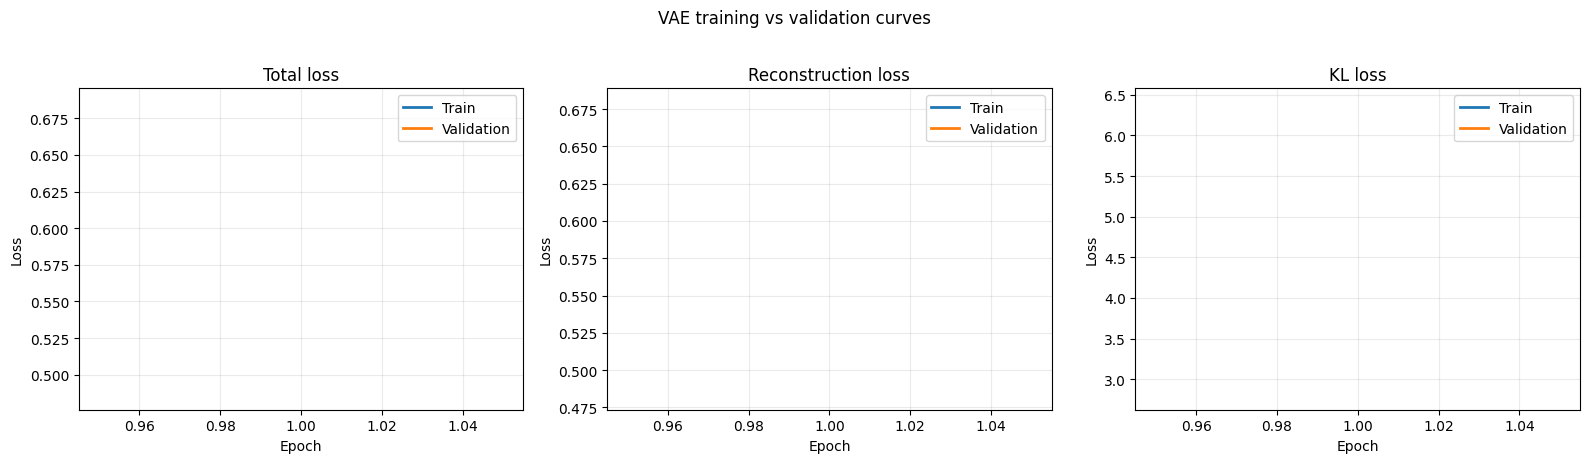

In [ ]:
# Training / validation loss curves (total + recon + KL)
epochs_ran = min(
    len(train_total_history), len(val_total_history),
    len(train_recon_history), len(val_recon_history),
    len(train_kl_history), len(val_kl_history),
)
epoch_axis = np.arange(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epoch_axis, train_total_history[:epochs_ran], label="Train", linewidth=2)
axes[0].plot(epoch_axis, val_total_history[:epochs_ran], label="Validation", linewidth=2)
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epoch_axis, train_recon_history[:epochs_ran], label="Train", linewidth=2)
axes[1].plot(epoch_axis, val_recon_history[:epochs_ran], label="Validation", linewidth=2)
axes[1].set_title("Reconstruction loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(epoch_axis, train_kl_history[:epochs_ran], label="Train", linewidth=2)
axes[2].plot(epoch_axis, val_kl_history[:epochs_ran], label="Validation", linewidth=2)
axes[2].set_title("KL loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(alpha=0.25)
axes[2].legend()

fig.suptitle("VAE training vs validation curves", y=1.02)
plt.tight_layout()

save_dir = SAVE_DIR / "vae_training_curves"
save_dir.mkdir(parents=True, exist_ok=True)
loss_curve_path = save_dir / "VAE_training_validation_curves.png"
fig.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
print(f"Saved loss curves to: {loss_curve_path}")

plt.show()

#### Save the weights

In [26]:
# Save trained ZINB VAE weights
save_dir = Path(r"C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths")
save_dir.mkdir(parents=True, exist_ok=True)
weights_path = save_dir / "VAE_ZINB_weights"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "log_theta": log_theta.detach().cpu(),
        "logit_pi": logit_pi.detach().cpu(),
        "gene_names": gene_names.tolist(),
        "best_epoch": best_epoch if "best_epoch" in globals() else None,
        "best_val_loss": float(best_val_loss) if "best_val_loss" in globals() else None,
    },
    weights_path,
)
print(f"Saved ZINB VAE weights to: {weights_path}")

Saved ZINB VAE weights to: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\VAE_ZINB_weights


#### Load the weights

In [53]:
# Load trained ZINB VAE weights (robust to fresh kernels)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_path = Path(r"C:\Users\ntpar\Downloads\VAE_ZINB_weights")
ckpt = torch.load(weights_path, map_location=device)

if "model_state_dict" not in ckpt:
    raise KeyError("Checkpoint is missing `model_state_dict`.")
state = ckpt["model_state_dict"]

# Infer architecture directly from checkpoint tensors.
if "enc_fc1.weight" not in state or "mu.weight" not in state or "out.weight" not in state:
    raise KeyError("Checkpoint model_state_dict is missing expected VAE layer weights.")

hidden_dim_ckpt = int(state["enc_fc1.weight"].shape[0])
latent_dim_ckpt = int(state["mu.weight"].shape[0])
input_dim_ckpt = int(state["out.weight"].shape[0])

# Keep gene_names consistent with the loaded checkpoint when available.
if "gene_names" in ckpt:
    gene_names = np.asarray(ckpt["gene_names"], dtype=object)

if "VAE" not in globals():
    raise NameError("VAE class is not defined. Run the VAE architecture cell first.")

rebuild_model = (
    "model" not in globals()
    or not isinstance(model, nn.Module)
    or getattr(getattr(model, "out", None), "out_features", None) != input_dim_ckpt
)
if rebuild_model:
    model = VAE(input_dim=input_dim_ckpt, latent_dim=latent_dim_ckpt, hidden_dim=hidden_dim_ckpt).to(device)

model.load_state_dict(state, strict=True)

# Rebuild or resize ZINB parameters if needed.
need_theta = (
    "log_theta" not in globals()
    or not isinstance(log_theta, torch.nn.Parameter)
    or int(log_theta.numel()) != input_dim_ckpt
)
need_pi = (
    "logit_pi" not in globals()
    or not isinstance(logit_pi, torch.nn.Parameter)
    or int(logit_pi.numel()) != input_dim_ckpt
)

if need_theta:
    if "log_theta" in ckpt:
        init_theta = ckpt["log_theta"].to(device=device, dtype=torch.float32)
    else:
        init_theta = torch.zeros(input_dim_ckpt, device=device, dtype=torch.float32)
    log_theta = nn.Parameter(init_theta.clone().detach())

if need_pi:
    if "logit_pi" in ckpt:
        init_pi = ckpt["logit_pi"].to(device=device, dtype=torch.float32)
    else:
        init_pi = torch.zeros(input_dim_ckpt, device=device, dtype=torch.float32)
    logit_pi = nn.Parameter(init_pi.clone().detach())

with torch.no_grad():
    if "log_theta" in ckpt:
        log_theta.copy_(ckpt["log_theta"].to(device))
    if "logit_pi" in ckpt:
        logit_pi.copy_(ckpt["logit_pi"].to(device))

model.eval()
print(f"Loaded weights from: {weights_path}")
print(f"Model dims from checkpoint: input={input_dim_ckpt}, hidden={hidden_dim_ckpt}, latent={latent_dim_ckpt}")
if "best_epoch" in ckpt and ckpt["best_epoch"] is not None:
    print(f"Checkpoint best_epoch: {ckpt['best_epoch']}")
if "best_val_loss" in ckpt and ckpt["best_val_loss"] is not None:
    print(f"Checkpoint best_val_loss: {ckpt['best_val_loss']:.6f}")

Loaded weights from: C:\Users\ntpar\Downloads\VAE_ZINB_weights
Model dims from checkpoint: input=343, hidden=256, latent=16
Checkpoint best_epoch: 28
Checkpoint best_val_loss: 0.528901


## Evaluation for VAE

### Loss & MSE 

In [ ]:
# -----------------------------
# Fast evaluation options
# -----------------------------
# Set QUICK_MODE=False for full evaluation once everything looks good.
QUICK_MODE = True
QUICK_MAX_CELLS = 20000        # None = all cells
QUICK_P_VALUES = [0.19]        # used only when QUICK_MODE=True
EVAL_BATCH_SIZE = 4096

# -----------------------------
# Sanity check: gene order must match checkpoint
# -----------------------------
ckpt_gene_names = np.asarray(ckpt.get("gene_names", []), dtype=str)
current_gene_names = np.asarray(gene_names, dtype=str)

if ckpt_gene_names.size > 0:
    if ckpt_gene_names.shape != current_gene_names.shape:
        raise ValueError(
            f"Gene dimension mismatch: checkpoint has {ckpt_gene_names.size}, "
            f"current pipeline has {current_gene_names.size}."
        )
    if not np.array_equal(ckpt_gene_names, current_gene_names):
        mismatch = np.flatnonzero(ckpt_gene_names != current_gene_names)
        first_bad = mismatch[:10]
        raise ValueError(
            "Checkpoint gene order does not match current `gene_names`.\n"
            f"First mismatches at indices: {first_bad.tolist()}"
        )

print("Checkpoint gene order matches current pipeline.")


# -----------------------------
# Helpers
# -----------------------------
def mse_counts(pred, true):
    pred = np.asarray(pred, dtype=np.float32)
    true = np.asarray(true, dtype=np.float32)
    return float(np.mean((pred - true) ** 2))

def mse_log1p(pred, true):
    pred = np.asarray(pred, dtype=np.float32)
    true = np.asarray(true, dtype=np.float32)
    return float(np.mean((np.log1p(pred) - np.log1p(true)) ** 2))

def build_scoreboard(x_true, x_vae, x_identity, gene_mean_train):
    x_gene_mean = np.broadcast_to(
        gene_mean_train.reshape(1, -1),
        x_true.shape,
    ).astype(np.float32, copy=False)

    rows = []
    for method_name, pred in {
        "VAE (ZINB expected decode)": x_vae,
        "Identity baseline (input passthrough)": x_identity,
        "Gene-mean baseline (train)": x_gene_mean,
    }.items():
        rows.append({
            "method": method_name,
            "mse_counts": mse_counts(pred, x_true),
            "mse_log1p": mse_log1p(pred, x_true),
        })

    return pd.DataFrame(rows).sort_values("mse_counts", ascending=True).reset_index(drop=True)


# -----------------------------
# Build/load dense test cache once (much faster than lazy backed per-row reads)
# -----------------------------
if "load_or_build_dense_split" not in globals():
    raise NameError("`load_or_build_dense_split` is not defined. Run the cached split builder cell first.")

if "CACHE_DIR" not in globals():
    CACHE_DIR = SAVE_DIR / "split_cache"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

test_cache = CACHE_DIR / f"test_{len(test_panel_ids)}panels_{n_genes}genes.npy"
Y_test = load_or_build_dense_split(
    panel_data=panel_data,
    panel_ids=test_panel_ids,
    common_genes=common_genes,
    cache_path=test_cache,
    dtype=np.float32,
    chunk_size=2048,
 )

if Y_test.ndim != 2 or Y_test.shape[1] != n_genes:
    raise ValueError(f"Unexpected Y_test shape: {Y_test.shape}, expected (_, {n_genes}).")


# -----------------------------
# Quick-mode subset/p-values
# -----------------------------
eval_p_values = np.asarray(QUICK_P_VALUES if QUICK_MODE else p_non_overlap_values, dtype=np.float64)
if np.any((eval_p_values < 0.0) | (eval_p_values > 1.0)):
    raise ValueError("All evaluation p values must be between 0 and 1.")

Y_test_eval = Y_test
selected_cell_idx = None
if QUICK_MODE and QUICK_MAX_CELLS is not None and QUICK_MAX_CELLS < Y_test.shape[0]:
    rng_sub = np.random.default_rng(base_seed + 2026)
    selected_cell_idx = np.sort(rng_sub.choice(Y_test.shape[0], size=int(QUICK_MAX_CELLS), replace=False))
    Y_test_eval = Y_test[selected_cell_idx]

print(f"Eval mode: {'QUICK' if QUICK_MODE else 'FULL'}")
print(f"Cells used: {Y_test_eval.shape[0]} / {Y_test.shape[0]}")
print(f"p values used: {eval_p_values.tolist()}")


# -----------------------------
# ZINB-style evaluation (vectorized corruption + batched inference)
# -----------------------------
model.eval()
pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)

all_recon_expected = []
all_true_counts = []
all_input_counts = []

test_loss_sum = 0.0
test_recon_sum = 0.0
test_kl_sum = 0.0
n_test_batches = 0

for version_idx, p_val in enumerate(eval_p_values):
    # Corrupt clean target deterministically for this p version.
    x_true_v = np.asarray(Y_test_eval, dtype=np.float32)
    x_in_v = x_true_v.copy()

    nz = x_in_v > 0
    if np.any(nz):
        counts = np.rint(x_in_v[nz]).astype(np.int64, copy=False)
        counts = np.clip(counts, 0, None)
        rng = np.random.default_rng(base_seed + version_idx * 1_000_003)
        x_in_v[nz] = rng.binomial(counts, float(p_val)).astype(np.float32, copy=False)

    # Batched inference on this p-version.
    n_cells_v = x_in_v.shape[0]
    recon_blocks = []
    for start in tqdm(range(0, n_cells_v, EVAL_BATCH_SIZE), desc=f"eval p={p_val:.3f}", unit="batch", leave=False):
        stop = min(start + EVAL_BATCH_SIZE, n_cells_v)
        xb_np = x_in_v[start:stop]
        yb_np = x_true_v[start:stop]

        xb = torch.from_numpy(xb_np).to(device, non_blocking=use_cuda)
        yb = torch.from_numpy(yb_np).to(device, non_blocking=use_cuda)

        with torch.inference_mode(), torch.cuda.amp.autocast(enabled=use_cuda):
            recon, mu, logvar = model(xb)
            t_loss, t_recon, t_kl = vae_loss(
                recon,
                yb,
                mu,
                logvar,
                beta=beta,
                loss_mask=None,
                theta_param=log_theta,
                zi_logits=logit_pi,
            )
            recon_mu = F.softplus(recon).float().cpu().numpy().astype(np.float32)

        recon_expected = recon_mu * (1.0 - pi_vec[None, :])
        recon_blocks.append(recon_expected)

        test_loss_sum += float(t_loss.item())
        test_recon_sum += float(t_recon.item())
        test_kl_sum += float(t_kl.item())
        n_test_batches += 1

    x_recon_v = np.concatenate(recon_blocks, axis=0)
    all_recon_expected.append(x_recon_v)
    all_true_counts.append(x_true_v)
    all_input_counts.append(x_in_v)

if n_test_batches == 0:
    raise RuntimeError("No test batches were produced.")

X_test_recon_nb = np.concatenate(all_recon_expected, axis=0)
X_test_tgt_nb = np.concatenate(all_true_counts, axis=0)
X_test_in_nb = np.concatenate(all_input_counts, axis=0)

# compatibility aliases if downstream cells expect these names
X_test_recon = np.asarray(X_test_recon_nb, dtype=np.float32)
X_test_tgt = np.asarray(X_test_tgt_nb, dtype=np.float32)

summary_table_nb = pd.DataFrame([
    {"metric": "test_total_loss_zinb", "value": test_loss_sum / n_test_batches},
    {"metric": "test_recon_loss_zinb", "value": test_recon_sum / n_test_batches},
    {"metric": "test_kl", "value": test_kl_sum / n_test_batches},
    {"metric": "test_MSE_counts", "value": mse_counts(X_test_recon_nb, X_test_tgt_nb)},
    {"metric": "test_MSE_log1p", "value": mse_log1p(X_test_recon_nb, X_test_tgt_nb)},
])

print("ZINB test summary (raw-count pipeline):")
display(summary_table_nb)


# -----------------------------
# Overall baseline scoreboard
# -----------------------------
x_true = np.asarray(X_test_tgt_nb, dtype=np.float32)
x_vae = np.asarray(X_test_recon_nb, dtype=np.float32)
x_identity = np.asarray(X_test_in_nb, dtype=np.float32)

x_train_tgt = np.asarray(Y_train.clip(min=0.0), dtype=np.float32)
gene_mean_train = x_train_tgt.mean(axis=0).astype(np.float32)

scoreboard_nb = build_scoreboard(
    x_true=x_true,
    x_vae=x_vae,
    x_identity=x_identity,
    gene_mean_train=gene_mean_train,
)

print("\nOverall baseline scoreboard (lower is better):")
display(scoreboard_nb)

ax = scoreboard_nb.plot(
    kind="bar",
    x="method",
    y="mse_counts",
    figsize=(8, 4),
    legend=False,
    rot=20,
)
ax.set_title("Overall test-set comparison")
ax.set_ylabel("MSE on counts (lower is better)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# -----------------------------
# Per-p analysis
# -----------------------------
n_versions = len(eval_p_values)
n_cells_per_version = int(Y_test_eval.shape[0])

per_p_rows = []
per_p_scoreboards = []

for version_idx, p_val in enumerate(eval_p_values):
    start = version_idx * n_cells_per_version
    stop = (version_idx + 1) * n_cells_per_version

    x_true_v = X_test_tgt_nb[start:stop]
    x_vae_v = X_test_recon_nb[start:stop]
    x_identity_v = X_test_in_nb[start:stop]

    sb_v = build_scoreboard(
        x_true=x_true_v,
        x_vae=x_vae_v,
        x_identity=x_identity_v,
        gene_mean_train=gene_mean_train,
    ).copy()

    sb_v.insert(0, "p_non_overlap", float(p_val))
    per_p_scoreboards.append(sb_v)

    per_p_rows.append({
        "p_non_overlap": float(p_val),
        "mse_counts_vae": mse_counts(x_vae_v, x_true_v),
        "mse_log1p_vae": mse_log1p(x_vae_v, x_true_v),
        "mse_counts_identity": mse_counts(x_identity_v, x_true_v),
        "mse_log1p_identity": mse_log1p(x_identity_v, x_true_v),
    })

per_p_summary = pd.DataFrame(per_p_rows)
scoreboard_by_p = pd.concat(per_p_scoreboards, ignore_index=True)

print("\nPer-p VAE vs identity summary:")
display(per_p_summary)

print("\nPer-p scoreboard:")
display(scoreboard_by_p)


# -----------------------------
# Per test split A / B / C analysis
# In quick-mode with subset sampling, split A/B/C cannot be reconstructed exactly from indices.
# -----------------------------
split_rows = []

if selected_cell_idx is None:
    group_defs = {
        "A": (0, test_a_cells),
        "B": (test_a_cells, test_a_cells + test_b_cells),
        "C": (test_a_cells + test_b_cells, test_a_cells + test_b_cells + test_c_cells),
    }

    for version_idx, p_val in enumerate(eval_p_values):
        version_offset = version_idx * n_cells_per_version

        for split_name, (g_start, g_stop) in group_defs.items():
            sl = slice(version_offset + g_start, version_offset + g_stop)

            x_true_g = X_test_tgt_nb[sl]
            x_vae_g = X_test_recon_nb[sl]
            x_identity_g = X_test_in_nb[sl]

            x_gene_mean_g = np.broadcast_to(
                gene_mean_train.reshape(1, -1),
                x_true_g.shape,
            ).astype(np.float32, copy=False)

            for method_name, pred in {
                "VAE (ZINB expected decode)": x_vae_g,
                "Identity baseline (input passthrough)": x_identity_g,
                "Gene-mean baseline (train)": x_gene_mean_g,
            }.items():
                split_rows.append({
                    "p_non_overlap": float(p_val),
                    "split": split_name,
                    "n_cells": int(x_true_g.shape[0]),
                    "method": method_name,
                    "mse_counts": mse_counts(pred, x_true_g),
                    "mse_log1p": mse_log1p(pred, x_true_g),
                })

    scoreboard_by_split = (
        pd.DataFrame(split_rows)
        .sort_values(["p_non_overlap", "split", "mse_counts"], ascending=[True, True, True])
        .reset_index(drop=True)
    )

    print("\nPer-split scoreboard:")
    display(scoreboard_by_split)

    vae_split_only = scoreboard_by_split[
        scoreboard_by_split["method"] == "VAE (ZINB expected decode)"
    ].copy()

    print("\nVAE-only per-split summary:")
    display(vae_split_only)
else:
    print("\nPer-split A/B/C analysis skipped in QUICK_MODE with random cell subset.")
    print("Set QUICK_MAX_CELLS=None (or QUICK_MODE=False) to enable exact split-wise metrics.")

Checkpoint gene order matches current pipeline.


ZINB test evaluation:   0%|          | 0/8330 [00:00<?, ?batch/s]

C:\Users\ntpar\AppData\Local\Temp\ipykernel_8160\807183523.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):
ZINB test evaluation:   1%|          | 61/8330 [09:05<20:32:04,  8.94s/batch]


KeyboardInterrupt: 

In [59]:
# This cell is kept as a lightweight compatibility view.
# Run the previous "Loss & MSE" cell for full evaluation.
print("Using evaluation outputs from the previous cell.")

if "summary_table_nb" in globals():
    print("\nZINB validation/test summary (raw-count pipeline):")
    display(summary_table_nb)
else:
    print("`summary_table_nb` not found. Run the previous evaluation cell first.")

if "scoreboard_nb" in globals():
    print("\nBaseline scoreboard (lower is better):")
    display(scoreboard_nb)
else:
    print("`scoreboard_nb` not found. Run the previous evaluation cell first.")

if "per_p_summary" in globals():
    print("\nPer-p VAE vs identity summary:")
    display(per_p_summary)

if "scoreboard_by_split" in globals():
    print("\nPer-split scoreboard:")
    display(scoreboard_by_split)

Using evaluation outputs from the previous cell.
`summary_table_nb` not found. Run the previous evaluation cell first.
`scoreboard_nb` not found. Run the previous evaluation cell first.


## Evaluation on reconstructed 5K
What the inference on 5K means: 
1. Take each 5K cell
2. Align it to the model gene space
3. Feed it through the trained VAE, decode it into ZINB parameters
4. Use the expected value of that ZINB distribution as the reconstructed expression profile.

#### Reconstructing the 5K 

In [106]:
# ZINB-style 5K -> V1-like reconstruction (strict model gene space, raw-count input)
# Inference-only cell: prepares reconstructed arrays and summary metrics for downstream plotting.
model.eval()

# Genes shared across model, 5K, and V1
genes_model = np.array(gene_names, dtype=object)
common_5k_model = np.intersect1d(genes_model, adata_5k.var_names.values)
common_v1_model = np.intersect1d(genes_model, adata_v1.var_names.values)
common_triplet = np.intersect1d(common_5k_model, common_v1_model)

print(f"Model genes (strict): {len(genes_model)}")
print(f"5K genes in model: {len(common_5k_model)}")
print(f"V1 genes in model: {len(common_v1_model)}")
print(f"(5K ∩ V1 ∩ model): {len(common_triplet)}")

if len(common_5k_model) == 0:
    raise ValueError("No overlap between 5K genes and model gene space.")
if len(common_v1_model) == 0:
    raise ValueError("No overlap between V1 genes and model gene space.")

# Build 5K raw-count input in strict model order
X5k_in = np.zeros((adata_5k.n_obs, len(genes_model)), dtype=np.float32)
model_pos = pd.Index(genes_model).get_indexer(common_5k_model)
g5k_pos = pd.Index(adata_5k.var_names).get_indexer(common_5k_model)
X5k_in[:, model_pos] = _to_dense_float32(adata_5k.X[:, g5k_pos])
X5k_in = np.clip(X5k_in, 0.0, None)

# Inference: expected counts under ZINB, E[X] = (1-pi) * mu
with torch.no_grad():
    xin = torch.tensor(X5k_in, dtype=torch.float32, device=device)
    raw_recon, _, _ = model(xin)
    mu_nb = torch.nn.functional.softplus(raw_recon).cpu().numpy().astype(np.float32)
    pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)
    X5k_recon_mu = mu_nb * (1.0 - pi_vec[None, :])

# Reconstructed AnnData
adata_5k_recon_nb = adata_5k.__class__(
    X=X5k_recon_mu,
    obs=adata_5k.obs.copy(),
    var=pd.DataFrame(index=genes_model),
)
adata_5k_recon_nb.obs_names = adata_5k.obs_names.copy()
adata_5k_recon = adata_5k_recon_nb

# Strict comparison set: model genes available in V1
strict_eval_genes = common_v1_model
idx_model_eval = pd.Index(genes_model).get_indexer(strict_eval_genes)
idx_v1_eval = pd.Index(adata_v1.var_names).get_indexer(strict_eval_genes)

X_recon_eval = X5k_recon_mu[:, idx_model_eval]
X_v1_eval = _to_dense_float32(adata_v1.X[:, idx_v1_eval])

# Stable aliases used by downstream cells
x_recon_eval = np.asarray(X_recon_eval, dtype=np.float32)
x_v1_eval = np.asarray(X_v1_eval, dtype=np.float32)
x_recon = x_recon_eval
x_v1 = x_v1_eval
model_genes = pd.Index(genes_model)

print(f"Cells -> recon from 5K: {X_recon_eval.shape[0]}, V1 reference: {X_v1_eval.shape[0]}")
print(f"Genes compared (strict): {X_recon_eval.shape[1]}")

finite_recon = np.isfinite(X_recon_eval).all()
finite_v1 = np.isfinite(X_v1_eval).all()
print(f"Finite check -> recon: {finite_recon}, v1: {finite_v1}")
if not (finite_recon and finite_v1):
    raise RuntimeError("Non-finite values detected in ZINB-style strict comparison arrays.")

# Gene-level metrics inputs
theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
theta_eval = theta_vec[idx_model_eval]
pi_eval = pi_vec[idx_model_eval]

mean_recon = X_recon_eval.mean(axis=0)
mean_v1 = X_v1_eval.mean(axis=0)
nb_p0 = np.power(theta_eval[None, :] / (theta_eval[None, :] + X_recon_eval + 1e-8), theta_eval[None, :])
p0 = pi_eval[None, :] + (1.0 - pi_eval[None, :]) * nb_p0
det_recon = (1.0 - p0).mean(axis=0)
det_v1 = (X_v1_eval > 0).mean(axis=0)

compare_zinb = pd.DataFrame([
    {
        "metric": "MSE_gene_mean_counts",
        "value": float(np.mean((mean_recon - mean_v1) ** 2)),
    },
    {
        "metric": "MSE_gene_mean_log1p",
        "value": float(np.mean((np.log1p(mean_recon) - np.log1p(mean_v1)) ** 2)),
    },
    {
        "metric": "MSE_gene_detection_rate_zinb_implied",
        "value": float(np.mean((det_recon - det_v1) ** 2)),
    },
])

# Compatibility alias used by plotting cells
metrics_df = compare_zinb.copy()

print("Inference complete for 5K -> V1 strict reconstruction.")
print("Prepared: adata_5k_recon, X_recon_eval, X_v1_eval, mean_recon, mean_v1, det_recon, det_v1, compare_zinb.")
display(compare_zinb)

Model genes (strict): 289
5K genes in model: 196
V1 genes in model: 289
(5K ∩ V1 ∩ model): 196
Cells -> recon from 5K: 262733, V1 reference: 188761
Genes compared (strict): 289
Finite check -> recon: True, v1: True
Inference complete for 5K -> V1 strict reconstruction.
Prepared: adata_5k_recon, X_recon_eval, X_v1_eval, mean_recon, mean_v1, det_recon, det_v1, compare_zinb.


,metric,value
0,MSE_gene_mean_counts,0.083405
1,MSE_gene_mean_log1p,0.011196
2,MSE_gene_detection_rate_zinb_implied,0.001661


#### Plot helper function

In [ ]:
# Exact-style subplot: y=x line, linear fit, n genes, Pearson r, and fit equation
def plot_exact_scatter_with_fit(
    x,
    y,
    title,
    x_label,
    y_label,
    color="#E68613",
    figsize=(7, 6),
    point_size=18,
    alpha=0.65,
    text_loc=(0.02, 0.98),
    line_pad=0.02,
    ax=None,
 ):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n_genes = x.size
    if n_genes < 2:
        raise ValueError("Need at least 2 valid points to fit a line.")

    slope, intercept = np.polyfit(x, y, 1)
    pearson_r = float(np.corrcoef(x, y)[0, 1])

    line_max = float(max(x.max(), y.max())) * (1.0 + line_pad) if n_genes > 0 else 1.0
    line_x = np.array([0.0, line_max], dtype=np.float64)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    ax.scatter(x, y, s=point_size, alpha=alpha, color=color)
    ax.plot(line_x, line_x, "k--", linewidth=1.2, alpha=0.8, label="y = x")
    ax.plot(line_x, slope * line_x + intercept, color=color, linewidth=1.6, alpha=0.95, label="fit")

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    ax.text(
        text_loc[0], text_loc[1],
        f"genes={n_genes}\nPearson r={pearson_r:.3f}\nfit: y={slope:.3f}x+{intercept:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    ax.set_xlim(-0.01 * line_max, line_max)
    ax.set_ylim(-0.01 * line_max, line_max)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return {
        "n_genes": int(n_genes),
        "pearson_r": pearson_r,
        "slope": float(slope),
        "intercept": float(intercept),
        "line_max": line_max,
    }

#### Standardized plotting 

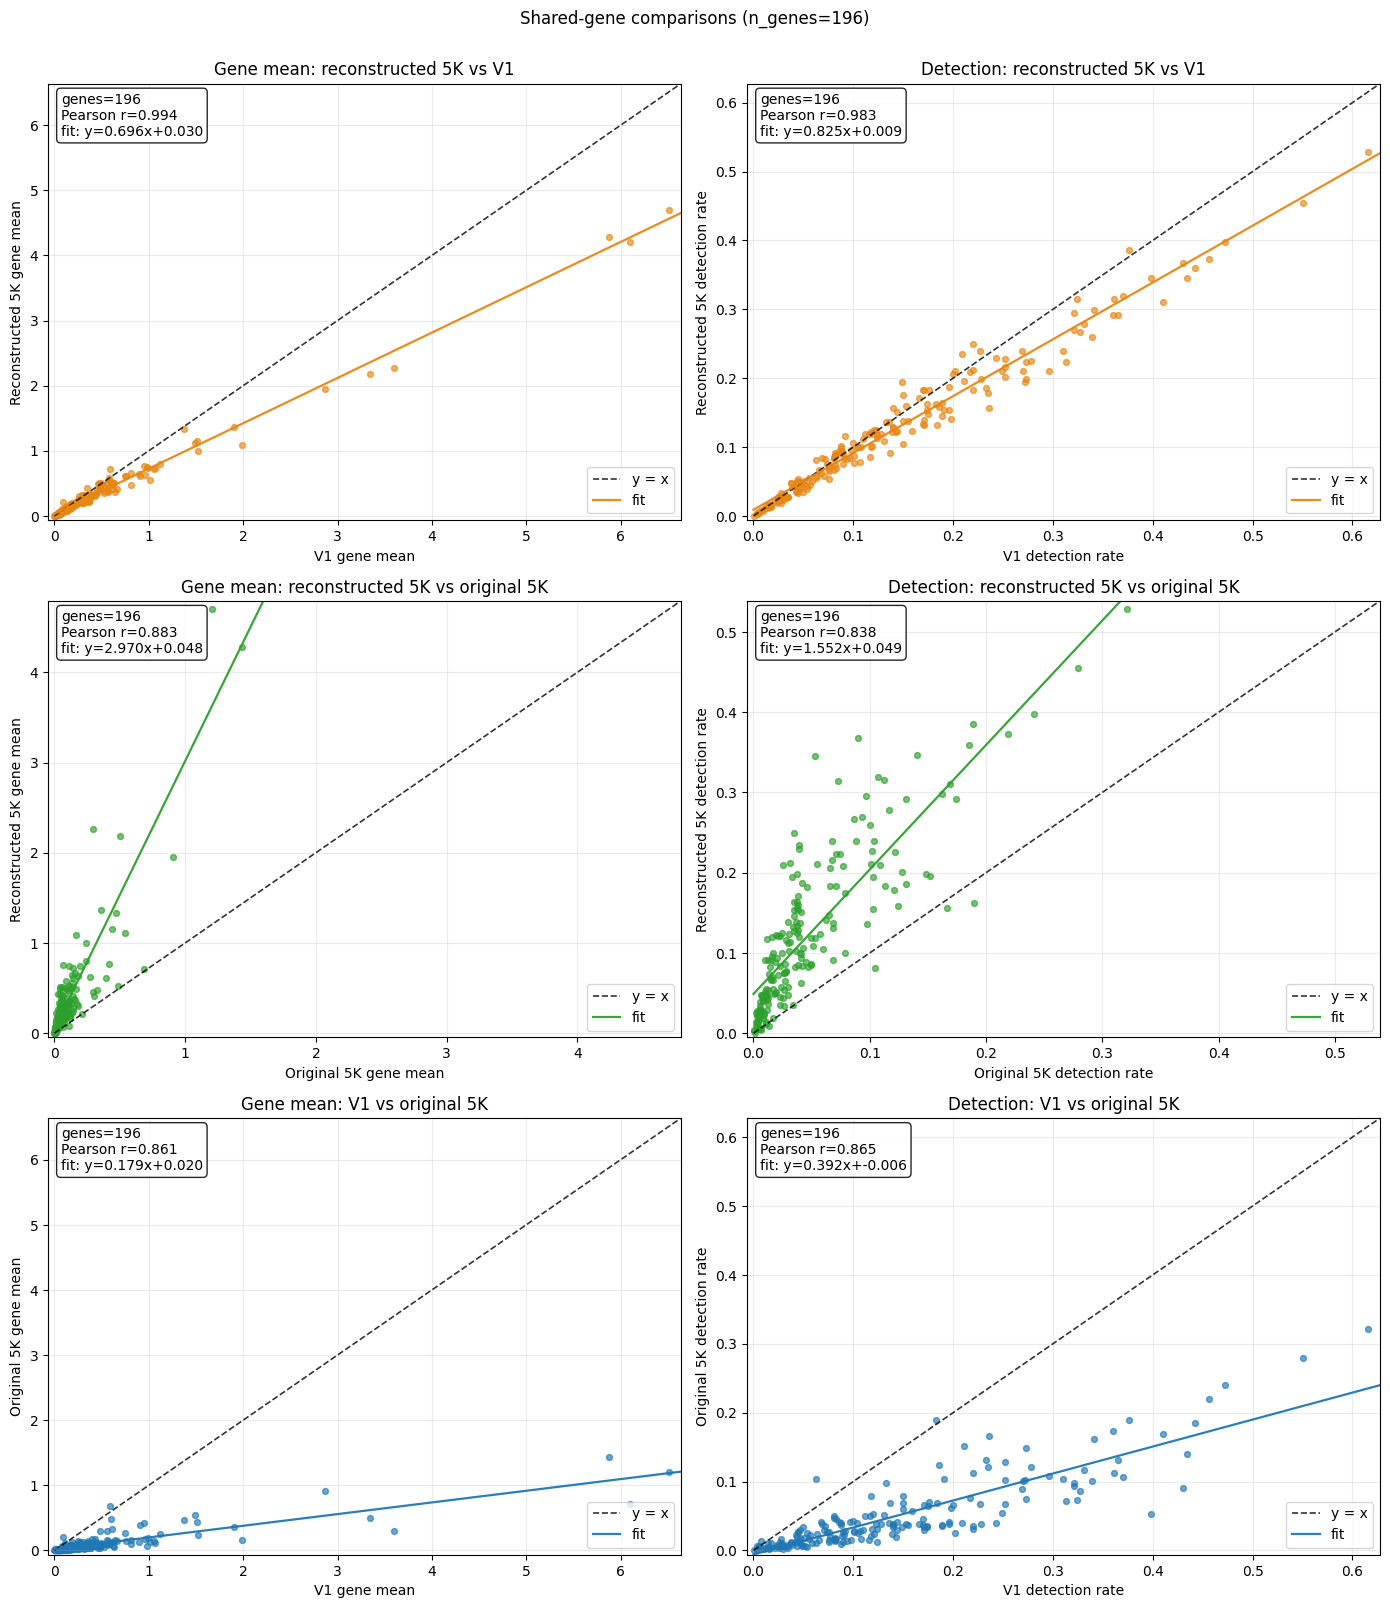

In [110]:
common_genes_all = pd.Index(adata_5k.var_names.astype(str))
common_genes_all = common_genes_all.intersection(pd.Index(adata_v1.var_names.astype(str)))
common_genes_all = common_genes_all.intersection(pd.Index(adata_5k_recon.var_names.astype(str)))
if len(common_genes_all) == 0:
    raise ValueError("No common genes across adata_5k, adata_v1, and adata_5k_recon.")

a5 = adata_5k[:, common_genes_all]
av = adata_v1[:, common_genes_all]
ar = adata_5k_recon[:, common_genes_all]

x5 = _to_dense_float32(a5.X) if "_to_dense_float32" in globals() else np.asarray(a5.X, dtype=np.float32)
xv = _to_dense_float32(av.X) if "_to_dense_float32" in globals() else np.asarray(av.X, dtype=np.float32)
xr_expected = _to_dense_float32(ar.X) if "_to_dense_float32" in globals() else np.asarray(ar.X, dtype=np.float32)

# Gene-level means
mean_5k = x5.mean(axis=0)
mean_v1 = xv.mean(axis=0)
mean_recon = xr_expected.mean(axis=0)

# Observed detection for originals
det_5k = (x5 > 0).mean(axis=0)
det_v1 = (xv > 0).mean(axis=0)

# Reconstructed detection: prefer ZINB-implied detection when parameters are available.
if "log_theta" in globals() and "logit_pi" in globals() and ("genes_model" in globals() or "gene_names" in globals()):
    model_genes_ref = np.array(globals().get("genes_model", globals().get("gene_names")), dtype=object)
    idx_model = pd.Index(model_genes_ref).get_indexer(common_genes_all)
    if np.any(idx_model < 0):
        # Fallback if alignment fails for any gene
        det_recon = (xr_expected > 0).mean(axis=0)
    else:
        theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
        pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)
        theta = np.clip(theta_vec[idx_model], 1e-8, None)
        pi = np.clip(pi_vec[idx_model], 1e-8, 1.0 - 1e-8)

        # xr_expected stores E[X] = (1-pi)*mu, recover mu for NB(0).
        mu_nb = xr_expected / (1.0 - pi[None, :] + 1e-8)
        nb_p0 = np.power(theta[None, :] / (theta[None, :] + np.clip(mu_nb, 0.0, None) + 1e-8), theta[None, :])
        p0 = pi[None, :] + (1.0 - pi[None, :]) * nb_p0
        det_recon = (1.0 - p0).mean(axis=0)
else:
    det_recon = (xr_expected > 0).mean(axis=0)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))


# Reconstructed vs V1
plot_exact_scatter_with_fit(
    x=mean_v1, y=mean_recon,
    title="Gene mean: reconstructed 5K vs V1",
    x_label="V1 gene mean",
    y_label="Reconstructed 5K gene mean",
    color="#E68613",
    ax=axes[0, 0],
)
plot_exact_scatter_with_fit(
    x=det_v1, y=det_recon,
    title="Detection: reconstructed 5K vs V1",
    x_label="V1 detection rate",
    y_label="Reconstructed 5K detection rate",
    color="#E68613",
    ax=axes[0, 1],
)

# Reconstructed vs 5K 
plot_exact_scatter_with_fit(
    x=mean_5k, y=mean_recon,
    title="Gene mean: reconstructed 5K vs original 5K",
    x_label="Original 5K gene mean",
    y_label="Reconstructed 5K gene mean",
    color="#2ca02c",
    ax=axes[1, 0],
)
plot_exact_scatter_with_fit(
    x=det_5k, y=det_recon,
    title="Detection: reconstructed 5K vs original 5K",
    x_label="Original 5K detection rate",
    y_label="Reconstructed 5K detection rate",
    color="#2ca02c",
    ax=axes[1, 1],
)

# V1 vs 5k
plot_exact_scatter_with_fit(
    x=mean_v1, y=mean_5k,
    title="Gene mean: V1 vs original 5K",
    x_label="V1 gene mean",
    y_label="Original 5K gene mean",
    color="#1f77b4",
    ax=axes[2, 0],
)
plot_exact_scatter_with_fit(
    x=det_v1, y=det_5k,
    title="Detection: V1 vs original 5K",
    x_label="V1 detection rate",
    y_label="Original 5K detection rate",
    color="#1f77b4",
    ax=axes[2, 1],
)

fig.suptitle(f"Shared-gene comparisons (n_genes={len(common_genes_all)})", y=1.002)
plt.tight_layout()
plt.show()

#### Per-gene histograms
**NOTE:** These were sampled according to the ZINB distribution, unlike the rest of the code up until now, where the expected value of the ZINB distribution was used 

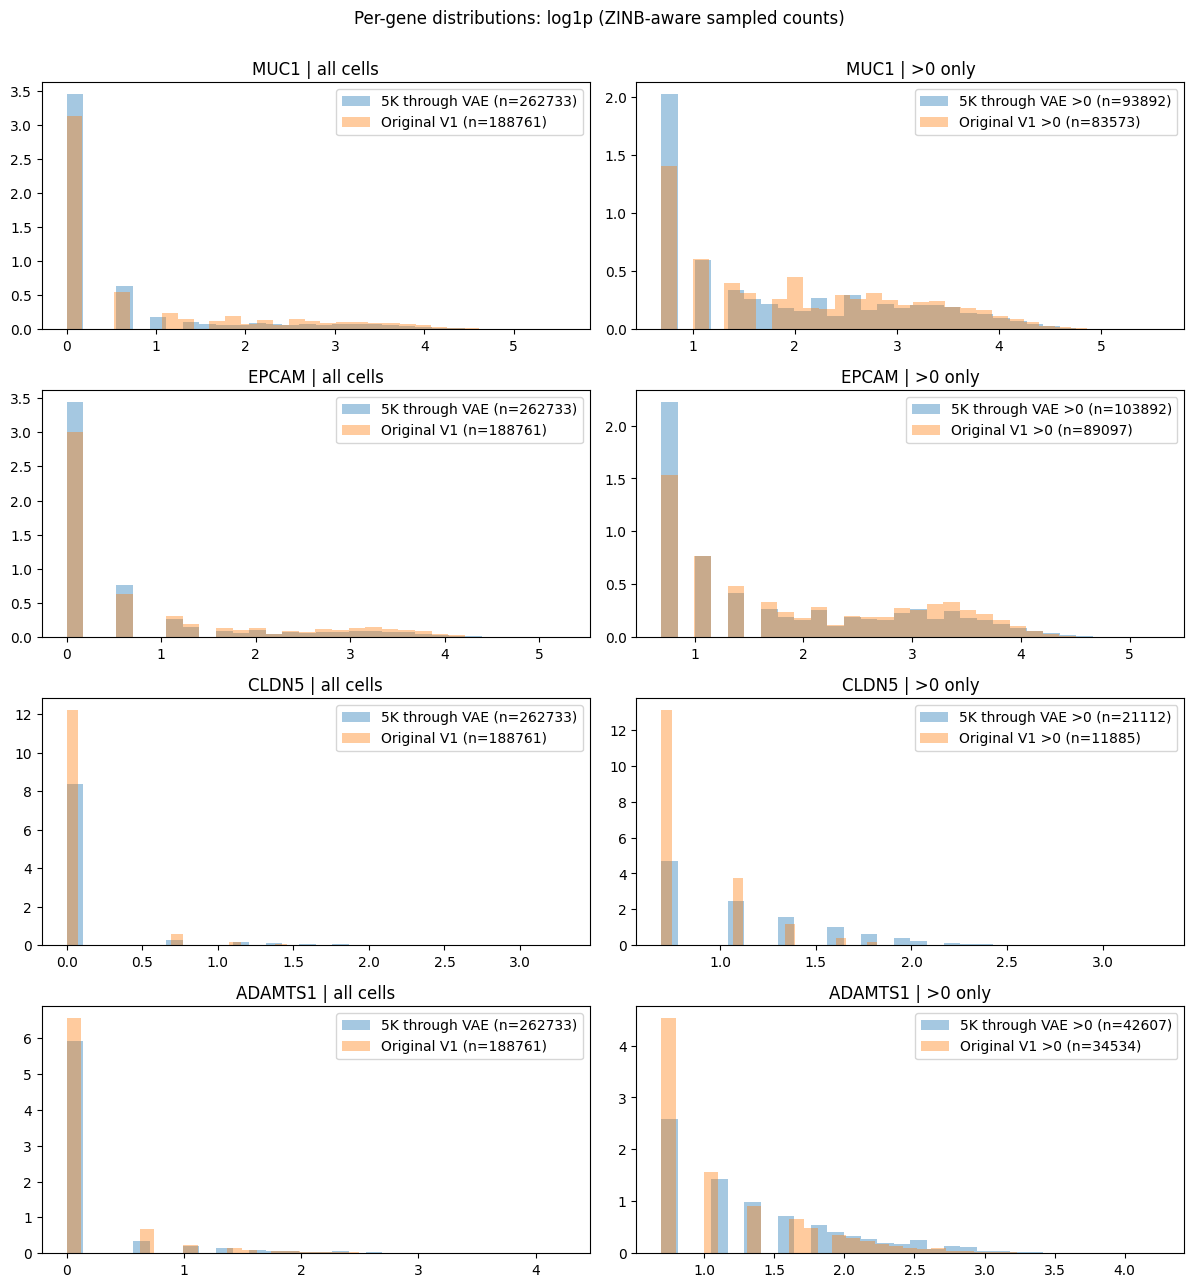

Per-gene summary (mean counts + detection %):


,gene,mean_first,mean_second,detect_pct_first_sampled,detect_pct_first_model_implied,detect_pct_second
0,MUC1,4.158674,6.095237,35.736660,35.806447,44.274506
1,EPCAM,4.243551,5.880161,39.542806,39.643481,47.200958
2,CLDN5,0.208615,0.091142,8.035534,8.067659,6.296322
3,ADAMTS1,0.710923,0.592707,16.216844,16.184409,18.295093


In [109]:
# Plotting-only cell for strict 5K->V1 reconstruction outputs

model_genes_arr = np.array(globals().get("model_genes", globals().get("genes_model", gene_names)), dtype=object)
x_v1_eval = np.asarray(globals().get("x_v1", globals().get("X_v1_eval")), dtype=np.float32)
x_recon_eval = np.asarray(globals().get("x_recon", globals().get("X_recon_eval")), dtype=np.float32)
zinb_mode = bool(globals().get("zinb_mode", True))

if x_v1_eval.shape[1] != x_recon_eval.shape[1]:
    raise ValueError(f"Gene dimension mismatch: x_v1_eval={x_v1_eval.shape}, x_recon_eval={x_recon_eval.shape}")

model_gene_pos = {g: i for i, g in enumerate(model_genes_arr)}
rng = np.random.default_rng(42)

theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)

n_rows = len(plot_genes)
fig, axs = plt.subplots(n_rows, 2, figsize=(12, 3.2 * n_rows), squeeze=False)

summary_rows = []
for i, gene in enumerate(plot_genes):
    g_idx = model_gene_pos[gene]
    xv_all = x_v1_eval[:, g_idx]

    if zinb_mode:
        mu_g = x_recon_eval[:, g_idx].astype(np.float32)
        theta_g = float(theta_vec[g_idx])
        pi_g = float(pi_vec[g_idx])

        lam = rng.gamma(shape=theta_g, scale=mu_g / (theta_g + 1e-8))
        x5_nb = rng.poisson(lam).astype(np.float32)
        drop_mask = rng.random(x5_nb.shape[0]) < pi_g
        x5_all = x5_nb
        x5_all[drop_mask] = 0.0

        det_model_implied = float(
            (
                1.0
                - (
                    pi_g
                    + (1.0 - pi_g)
                    * np.power(theta_g / (theta_g + np.clip(x_recon_eval[:, g_idx], 0.0, None) + 1e-8), theta_g)
                )
            ).mean()
        )
    else:
        x5_all = x_recon_eval[:, g_idx].astype(np.float32)
        det_model_implied = float((x5_all > 0).mean())

    x5_pos = x5_all[x5_all > 0]
    xv_pos = xv_all[xv_all > 0]

    x5_plot_all = np.log1p(np.clip(x5_all, 0.0, None))
    xv_plot_all = np.log1p(np.clip(xv_all, 0.0, None))
    x5_plot_pos = np.log1p(np.clip(x5_pos, 0.0, None))
    xv_plot_pos = np.log1p(np.clip(xv_pos, 0.0, None))

    axL = axs[i, 0]
    axL.hist(x5_plot_all, bins=30, density=True, alpha=0.4, label=f"5K through VAE (n={len(x5_plot_all)})")
    axL.hist(xv_plot_all, bins=30, density=True, alpha=0.4, label=f"Original V1 (n={len(xv_plot_all)})")
    axL.set_title(f"{gene} | all cells")
    axL.legend(frameon=True)

    axR = axs[i, 1]
    if x5_plot_pos.size > 0:
        axR.hist(x5_plot_pos, bins=30, density=True, alpha=0.4, label=f"5K through VAE >0 (n={len(x5_plot_pos)})")
    if xv_plot_pos.size > 0:
        axR.hist(xv_plot_pos, bins=30, density=True, alpha=0.4, label=f"Original V1 >0 (n={len(xv_plot_pos)})")
    axR.set_title(f"{gene} | >0 only")
    axR.legend(frameon=True)

    summary_rows.append(
        {
            "gene": gene,
            "mean_first": float(np.mean(x5_all)),
            "mean_second": float(np.mean(xv_all)),
            "detect_pct_first_sampled": float(100.0 * np.mean(x5_all > 0)),
            "detect_pct_first_model_implied": float(100.0 * det_model_implied),
            "detect_pct_second": float(100.0 * np.mean(xv_all > 0)),
        }
    )

fig.suptitle("Per-gene distributions: log1p (ZINB-aware sampled counts)", y=1.002)
plt.tight_layout()
plt.show()

print("Per-gene summary (mean counts + detection %):")
display(pd.DataFrame(summary_rows))

## Rebuilding from trained cluster

In [58]:
# ---------------------------------------------------------------------
# 5K -> V1 strict reconstruction analysis using TENX189 (5K) and TENX190 (V1)
# Paste after the best checkpoint has been loaded.
# ---------------------------------------------------------------------

import anndata as ad

sample_5k_id = "TENX189"
sample_v1_id = "TENX190"

if sample_5k_id not in panel_data:
    raise KeyError(f"{sample_5k_id} not found in panel_data. Make sure it is still in the loaded test panels.")
if sample_v1_id not in panel_data:
    raise KeyError(f"{sample_v1_id} not found in panel_data. Make sure it is still in the loaded test panels.")


def materialize_filtered_panel(panel_data, sample_id, dtype=np.float32, chunk_size=2048):
    """
    Rebuild one panel as an in-memory AnnData using the same filtered cells/genes
    that were used by the cluster pipeline.
    """
    rec = panel_data[sample_id]
    ad_panel = rec["adata"]
    rows = np.asarray(rec["cell_pos"], dtype=np.int64)
    cols = np.asarray(rec["gene_pos_all"], dtype=np.int64)

    X = np.empty((len(rows), len(cols)), dtype=dtype)

    for start in tqdm(range(0, len(rows), chunk_size), desc=f"Materializing {sample_id}", unit="chunk"):
        stop = min(start + chunk_size, len(rows))
        block_rows = rows[start:stop]

        try:
            block = ad_panel[block_rows, cols].X
            if sp.issparse(block):
                block = block.toarray()
            else:
                block = np.asarray(block)
        except Exception:
            block_rows_list = []
            for r in block_rows:
                row = ad_panel.X[int(r), cols]
                if sp.issparse(row):
                    row = row.toarray().ravel()
                else:
                    row = np.asarray(row).ravel()
                block_rows_list.append(row)
            block = np.vstack(block_rows_list)

        X[start:stop] = block.astype(dtype, copy=False)

    X = np.clip(X, 0.0, None)

    obs = ad_panel.obs.iloc[rows].copy()
    obs_names = pd.Index(ad_panel.obs_names.astype(str))[rows].copy()
    var_names = pd.Index(rec["gene_names"]).astype(str)

    adata_out = ad.AnnData(
        X=X,
        obs=obs,
        var=pd.DataFrame(index=var_names),
    )
    adata_out.obs_names = obs_names
    return adata_out


def zinb_expected_counts_batched(model, X_in, logit_pi, device, batch_size=1024):
    """
    Compute E[X] = (1 - pi) * mu in batches to avoid GPU/CPU memory spikes.
    """
    model.eval()
    pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)

    out_blocks = []
    with torch.no_grad():
        for start in tqdm(range(0, X_in.shape[0], batch_size), desc="ZINB inference", unit="batch"):
            stop = min(start + batch_size, X_in.shape[0])
            xin = torch.from_numpy(X_in[start:stop]).to(device, non_blocking=torch.cuda.is_available())

            raw_recon, _, _ = model(xin)
            mu_nb = torch.nn.functional.softplus(raw_recon).cpu().numpy().astype(np.float32)
            out_blocks.append(mu_nb * (1.0 - pi_vec[None, :]))

    return np.vstack(out_blocks), pi_vec


# Rebuild filtered panel objects
adata_5k = materialize_filtered_panel(panel_data, sample_5k_id)
adata_v1 = materialize_filtered_panel(panel_data, sample_v1_id)

print(f"{sample_5k_id} cells x genes: {adata_5k.shape}")
print(f"{sample_v1_id} cells x genes: {adata_v1.shape}")

# ---------------------------------------------------------------------
# ZINB-style 5K -> V1-like reconstruction (strict model gene space, raw-count input)
# ---------------------------------------------------------------------
model.eval()

# Genes shared across model, 5K, and V1
genes_model = np.array(gene_names, dtype=object)
common_5k_model = np.intersect1d(genes_model, adata_5k.var_names.values)
common_v1_model = np.intersect1d(genes_model, adata_v1.var_names.values)
common_triplet = np.intersect1d(common_5k_model, common_v1_model)

print(f"Model genes (strict): {len(genes_model)}")
print(f"5K genes in model: {len(common_5k_model)}")
print(f"V1 genes in model: {len(common_v1_model)}")
print(f"(5K ∩ V1 ∩ model): {len(common_triplet)}")

if len(common_5k_model) == 0:
    raise ValueError("No overlap between 5K genes and model gene space.")
if len(common_v1_model) == 0:
    raise ValueError("No overlap between V1 genes and model gene space.")

# Build 5K raw-count input in strict model order
X5k_in = np.zeros((adata_5k.n_obs, len(genes_model)), dtype=np.float32)
model_pos = pd.Index(genes_model).get_indexer(common_5k_model)
g5k_pos = pd.Index(adata_5k.var_names).get_indexer(common_5k_model)
X5k_in[:, model_pos] = _to_dense_float32(adata_5k.X[:, g5k_pos])
X5k_in = np.clip(X5k_in, 0.0, None)

# Inference: expected counts under ZINB, E[X] = (1-pi) * mu
X5k_recon_mu, pi_vec = zinb_expected_counts_batched(
    model=model,
    X_in=X5k_in,
    logit_pi=logit_pi,
    device=device,
    batch_size=1024,
)

# Reconstructed AnnData
adata_5k_recon_nb = ad.AnnData(
    X=X5k_recon_mu,
    obs=adata_5k.obs.copy(),
    var=pd.DataFrame(index=pd.Index(genes_model).astype(str)),
)
adata_5k_recon_nb.obs_names = adata_5k.obs_names.copy()
adata_5k_recon = adata_5k_recon_nb

# Strict comparison set: model genes available in V1
strict_eval_genes = common_v1_model
idx_model_eval = pd.Index(genes_model).get_indexer(strict_eval_genes)
idx_v1_eval = pd.Index(adata_v1.var_names).get_indexer(strict_eval_genes)

X_recon_eval = X5k_recon_mu[:, idx_model_eval]
X_v1_eval = _to_dense_float32(adata_v1.X[:, idx_v1_eval])

# Stable aliases used by downstream cells
x_recon_eval = np.asarray(X_recon_eval, dtype=np.float32)
x_v1_eval = np.asarray(X_v1_eval, dtype=np.float32)
x_recon = x_recon_eval
x_v1 = x_v1_eval
model_genes = pd.Index(genes_model)

print(f"Cells -> recon from 5K: {X_recon_eval.shape[0]}, V1 reference: {X_v1_eval.shape[0]}")
print(f"Genes compared (strict): {X_recon_eval.shape[1]}")

finite_recon = np.isfinite(X_recon_eval).all()
finite_v1 = np.isfinite(X_v1_eval).all()
print(f"Finite check -> recon: {finite_recon}, v1: {finite_v1}")
if not (finite_recon and finite_v1):
    raise RuntimeError("Non-finite values detected in ZINB-style strict comparison arrays.")

# Gene-level metrics inputs
theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
theta_eval = theta_vec[idx_model_eval]
pi_eval = pi_vec[idx_model_eval]

mean_recon = X_recon_eval.mean(axis=0)
mean_v1 = X_v1_eval.mean(axis=0)
nb_p0 = np.power(theta_eval[None, :] / (theta_eval[None, :] + X_recon_eval + 1e-8), theta_eval[None, :])
p0 = pi_eval[None, :] + (1.0 - pi_eval[None, :]) * nb_p0
det_recon = (1.0 - p0).mean(axis=0)
det_v1 = (X_v1_eval > 0).mean(axis=0)

compare_zinb = pd.DataFrame([
    {
        "metric": "MSE_gene_mean_counts",
        "value": float(np.mean((mean_recon - mean_v1) ** 2)),
    },
    {
        "metric": "MSE_gene_mean_log1p",
        "value": float(np.mean((np.log1p(mean_recon) - np.log1p(mean_v1)) ** 2)),
    },
    {
        "metric": "MSE_gene_detection_rate_zinb_implied",
        "value": float(np.mean((det_recon - det_v1) ** 2)),
    },
])

# Compatibility alias used by plotting cells
metrics_df = compare_zinb.copy()

print("Inference complete for 5K -> V1 strict reconstruction.")
print("Prepared: adata_5k_recon, X_recon_eval, X_v1_eval, mean_recon, mean_v1, det_recon, det_v1, compare_zinb.")
display(compare_zinb)

KeyError: 'TENX190 not found in panel_data. Make sure it is still in the loaded test panels.'